# Solar Irradiation Model — Clearness Index Marginal

## Objective
Fit the clearness-index marginal `Kt = GHI / CLEAR_SKY_GHI` that the copula
and the Monte Carlo simulation draw solar-output paths from: a rescaled logit
transform, a one-harmonic seasonal mean, an ARMA on the deseasonalized
residual, and a two-component Gaussian mixture per calendar month on the
ARMA residual.

## Pipeline Position

| Inputs | This notebook | Outputs |
|---|---|---|
| `Data/Cleaned/df_bologna_cleaned.parquet` | Fit Kt marginal | `Data/Modelled/df_solar_modelled.parquet` |
| | | `Code/Models/GHI - KT/{ghi_arma_result, ghi_mixture_params, ghi_seasonal_coeffs}.pkl` |
| | | `Code/Models/GHI - KT/model_meta.json` |

## Decision Log

| # | Decision | Alternatives | Rationale | Impact |
|---|---|---|---|---|
| D1 | Rescaled logit of cloudiness `X = 1 - Kt`, not of `Kt` directly | Model `Kt` on its natural (0,1] scale | Keeps every simulated draw in the physical range without truncation | `Y_t` is increasing in cloudiness: low `Y_t` = clear, high `Y_t` = overcast |
| D2 | One-harmonic (annual only) seasonal mean, day-of-year phase | Two harmonics (better fit) | `ghi_seasonal_coeffs.pkl` is a 3-element vector the reconstruction notebooks unpack positionally; a second harmonic would break that contract | Any residual monthly offset the single harmonic misses is absorbed by the monthly mixture means instead, so seasonality is split across two places by design |
| D3 | ARMA order selected by BIC over p,q in 0..3 | Fixed order | Full-sample BIC grid, no manual override | See Limitations — the same order is then reused in the train-only holdout refit |
| D4 | Two-component Gaussian mixture per calendar month on the ARMA residual, sorted by mean | A single Gaussian, or a mixture shared across months | ARCH-LM does not reject on this residual (constant variance is supported), but the residual is genuinely bimodal within most months — a clear-sky mode and an overcast mode, with a mix that shifts month to month | Component 0 (lower mean) is the clear regime, component 1 (higher mean) the cloudy regime, verified against the fitted means each run rather than assumed from component order |
| D5 | Support of simulated `Kt` is capped by the sample's own min/max via alpha/beta | An unbounded transform | Guarantees the logit inversion never leaves (0,1] | The simulation can never generate a day cloudier than the cloudiest observed day — a real limitation for downside-risk work built on these paths, see Limitations |

## Setup

In [1]:
import json
import pickle
import warnings
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.stats import gaussian_kde, kstest, norm, binom
from sklearn.mixture import GaussianMixture

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

import sys
sys.path.append(str(Path("..").resolve()))
from model_utils import find_project_root, daily_features

ROOT = find_project_root()

## Load Data

In [2]:
df = pd.read_parquet(ROOT / "Data" / "Cleaned" / "df_bologna_cleaned.parquet")

## Daily Aggregation

In [3]:
df_daily = daily_features(df)

In [4]:
# ── Data continuity check ────────────────────────────────────────────────────
#
# Both the ARMA recursion and the Fourier seasonal term assume a complete,
# strictly increasing daily index. Gaps or duplicate dates silently corrupt
# the lag structure without raising an error, so they are detected here,
# before anything is fitted.

_dates   = pd.DatetimeIndex(df_daily["date"]).sort_values()
_n_dup   = int(_dates.duplicated().sum())
_full    = pd.date_range(_dates.min(), _dates.max(), freq="D")
_missing = _full.difference(_dates)

print(f"Daily series  : {_dates.min().date()} → {_dates.max().date()}")
print(f"  observed days : {len(_dates):,}")
print(f"  expected days : {len(_full):,}")
print(f"  duplicates    : {_n_dup}")
print(f"  missing days  : {len(_missing)}")
if len(_missing) > 0:
    print(f"  first 10 gaps : {[d.date() for d in _missing[:10]]}")

assert _n_dup == 0, "duplicate dates in df_daily — aggregation produced repeats"

# Kt must lie in (0, 1] for the logit transform to be well defined
_kt_chk = df_daily["Kt_daily"].dropna()
_n_bad  = int(((_kt_chk <= 0) | (_kt_chk > 1)).sum())
print(f"  Kt range      : [{_kt_chk.min():.4f}, {_kt_chk.max():.4f}]")
print(f"  Kt outside (0,1] : {_n_bad}")
print(f"  Kt NaN        : {int(df_daily['Kt_daily'].isna().sum())}")

Daily series  : 2005-01-01 → 2025-12-31
  observed days : 7,670
  expected days : 7,670
  duplicates    : 0
  missing days  : 0
  Kt range      : [0.0907, 1.0000]
  Kt outside (0,1] : 0
  Kt NaN        : 0


## Rescaled Logit Transform  (D1)

In [5]:
EPS = 1e-3

def transform_kt_to_Yt(
    kt: pd.Series,
) -> tuple[pd.Series, dict]:
    """
    Map Kt_daily ∈ (0,1] to an unbounded Y_t ∈ ℝ using a rescaled logit link.

    The transform is applied to the CLOUDINESS X_t = 1 − Kt, so Y_t is
    increasing in cloudiness: high Y_t = overcast, low Y_t = clear sky.
    α and β rescale X_t into (0,1) strictly, so the logit never diverges.

    Returns
    -------
    Yt     : pd.Series — unbounded transformed series
    params : dict      — α, β (required for inversion)
    """
    # D1: transform is applied to CLOUDINESS (1 - Kt), not Kt directly.
    Xt = 1.0 - kt

    # D5: support capped by the sample's own min/max, not a fixed physical
    # bound -- no simulated day can be cloudier than the cloudiest observed one.
    alpha = float(Xt.min()) - EPS
    beta  = float(Xt.max() - Xt.min()) + 2 * EPS

    Xp = (Xt - alpha) / beta                          # X'_t ∈ (0, 1) strictly
    Yt = pd.Series(
        np.log(Xp.values / (1.0 - Xp.values)),        # logit
        index=kt.index,
        name="Y_t"
    )

    return Yt, {"alpha": alpha, "beta": beta}


def invert_Yt_to_Kt(
    Yt,
    params: dict,
):
    """
    Recover Kt = 1 − (α + β·σ(Y_t)), where σ is the logistic function.
    Guarantees Kt ∈ [1−α−β, 1−α] ⊂ [0, 1] without truncation.
    """
    alpha, beta = params["alpha"], params["beta"]
    Xp_rec = 1.0 / (1.0 + np.exp(-np.asarray(Yt, dtype=float)))
    return 1.0 - (alpha + beta * Xp_rec)


def invert_Yt_to_GHI(
    Yt: pd.Series,
    Ct: pd.Series,
    params: dict
) -> pd.Series:
    """
    Recover R_t = C_t · Kt(Y_t) ∈ [0, C_t] without truncation.
    """
    return pd.Series(
        Ct.values * invert_Yt_to_Kt(Yt.values, params),
        index=Yt.index,
        name="GHI_reconstructed"
    )

In [6]:
kt  = df_daily.set_index("date")["Kt_daily"].dropna()
Ct  = df_daily.set_index("date")["GHI_cs_sum"].loc[kt.index]

Yt, params = transform_kt_to_Yt(kt)

# Inversion check — RMSE should be ≈ 0
GHI_rec = invert_Yt_to_GHI(Yt, Ct, params)
GHI_obs = df_daily.set_index("date")["GHI_sum"].loc[kt.index]
rmse    = np.sqrt(((GHI_obs - GHI_rec) ** 2).mean())

print(f"α = {params['alpha']:.6f},  β = {params['beta']:.6f}")
print(f"Y_t range : [{Yt.min():.3f}, {Yt.max():.3f}]")
print(f"Inversion RMSE : {rmse:.2e} kWh/m²  (expected ≈ 0)")

α = -0.001000,  β = 0.911341
Y_t range : [-6.814, 6.814]
Inversion RMSE : 1.91e-13 kWh/m²  (expected ≈ 0)


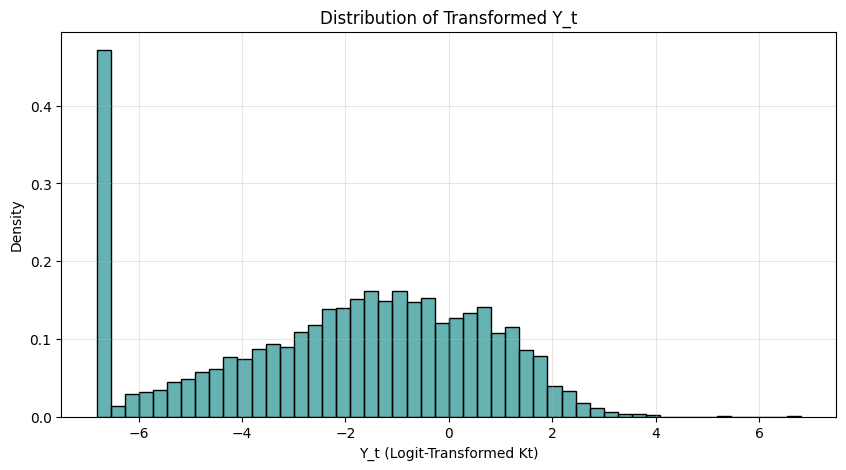

In [7]:
# check the distribution of Yt
plt.figure(figsize=(10, 5))
sns.histplot(Yt, bins=50, color='teal', alpha=0.6, stat='density')
plt.title("Distribution of Transformed Y_t", fontsize=12)
plt.xlabel("Y_t (Logit-Transformed Kt)")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()


> **Takeaway.** `Y_t` is unimodal and roughly symmetric, with no boundary pile-up at the alpha/beta support edges -- the logit transform is behaving as a genuine unbounding, not a truncation in disguise.

## Remove the Deterministic Seasonal Mean  (D2)

In [8]:
# D2: one annual harmonic only -- ghi_seasonal_coeffs.pkl is unpacked
# positionally by the reconstruction notebooks, so its length is a contract.
# Y_t still carries a predictable intra-annual cycle inherited from the
# astronomical seasonality of GHI. A trigonometric function absorbs this.
#
#   Ȳ_t = a0 + a1·cos(2π·doy/365) + a2·sin(2π·doy/365)
#   Ỹ_t = Y_t − Ȳ_t
#
# The phase argument is CALENDAR day-of-year, not the positional index of the
# series. A positional index accumulates one day of phase error per leap year
# (~5 days over 2005–2025) and shifts arbitrarily if the series has gaps.
# Day-of-year is also the convention the downstream reconstruction notebooks
# use when they re-evaluate Ȳ_t from the saved coefficients, so the two agree.

SEASONAL_PERIOD = 365.0   # days — phase period of the annual harmonic


def seasonal_design(dates: pd.DatetimeIndex) -> np.ndarray:
    """
    Build the Fourier design matrix [1, cos(2π·doy/T), sin(2π·doy/T)].

    Depends only on the calendar, so it can be evaluated on any date range
    (train, test, or future simulation) without reference to series position.
    """
    doy   = pd.DatetimeIndex(dates).dayofyear.values.astype(float)
    t_rad = 2 * np.pi * doy / SEASONAL_PERIOD
    return np.column_stack([np.ones(len(doy)), np.cos(t_rad), np.sin(t_rad)])


def remove_seasonal_mean(
    Yt: pd.Series,
) -> tuple[pd.Series, pd.Series, np.ndarray]:
    """
    Fit a trigonometric seasonal mean on Y_t and return the deseasonalized series.

    Returns
    -------
    Y_tilde : pd.Series  — deseasonalized series Ỹ_t = Y_t − Ȳ_t
    Y_bar   : pd.Series  — fitted seasonal mean Ȳ_t
    a       : np.ndarray — estimated coefficients [a0, a1, a2]
    """
    X = seasonal_design(Yt.index)

    a       = np.linalg.lstsq(X, Yt.values, rcond=None)[0]
    Y_bar   = pd.Series(X @ a,             index=Yt.index, name="Y_bar")
    Y_tilde = pd.Series(Yt.values - Y_bar, index=Yt.index, name="Y_tilde")

    return Y_tilde, Y_bar, a


# ── Usage ─────────────────────────────────────────────────────────────────────

Y_tilde, Y_bar, a = remove_seasonal_mean(Yt)

print(f"Seasonal coefficients:  a0={a[0]:.4f},  a1={a[1]:.4f},  a2={a[2]:.4f}")
print(f"Seasonal amplitude   :  {np.hypot(a[1], a[2]):.4f}  "
      f"(peak at doy {int(np.argmax(seasonal_design(pd.date_range('2023-01-01', periods=365)) @ a)) + 1})")
print(f"Y_tilde mean  : {Y_tilde.mean():.4f}  (expected ≈ 0)")
print(f"Y_tilde range : [{Y_tilde.min():.3f}, {Y_tilde.max():.3f}]")

# ── Diagnostics ───────────────────────────────────────────────────────────────

# ADF test — null: unit root (non-stationary); reject → stationary
adf_stat, adf_p, *_ = adfuller(Y_tilde.dropna())
print(f"\nADF statistic : {adf_stat:.4f},  p-value : {adf_p:.4f}  (reject H0 if p < 0.05)")

# Ljung-Box — null: no autocorrelation; significant lags indicate remaining
# structure. Strong rejection here is EXPECTED: the seasonal mean removes the
# annual cycle only, leaving the day-to-day persistence for the ARMA to absorb.
lb = acorr_ljungbox(Y_tilde.dropna(), lags=[7, 30, 365], return_df=True)
print(f"\nLjung-Box on Ỹ_t (lags 7, 30, 365):")
print(lb[["lb_stat", "lb_pvalue"]].to_string())

# Durbin-Watson — values near 2 indicate no first-order autocorrelation
dw = durbin_watson(Y_tilde.dropna())
print(f"\nDurbin-Watson : {dw:.4f}  (near 2 = no AR(1) autocorrelation)")

# Residual seasonality check — a single harmonic may leave a semi-annual
# component. Monthly means of Ỹ_t should be ≈ 0 if the cycle is fully absorbed.
_m_mean = Y_tilde.groupby(Y_tilde.index.month).mean()
print(f"\nMonthly means of Ỹ_t (0 ⇒ seasonality fully absorbed):")
print("  " + "  ".join(f"{m:02d}:{v:+.3f}" for m, v in _m_mean.items()))
print(f"  max |monthly mean| = {_m_mean.abs().max():.3f}")

Seasonal coefficients:  a0=-2.1033,  a1=0.8885,  a2=0.2198
Seasonal amplitude   :  0.9153  (peak at doy 14)
Y_tilde mean  : 0.0000  (expected ≈ 0)
Y_tilde range : [-5.626, 8.251]



ADF statistic : -22.9378,  p-value : 0.0000  (reject H0 if p < 0.05)

Ljung-Box on Ỹ_t (lags 7, 30, 365):
         lb_stat  lb_pvalue
7    1944.990561        0.0
30   2105.714259        0.0
365  3022.275560        0.0

Durbin-Watson : 1.1665  (near 2 = no AR(1) autocorrelation)

Monthly means of Ỹ_t (0 ⇒ seasonality fully absorbed):
  01:-0.056  02:-0.338  03:-0.396  04:+0.025  05:+0.726  06:+0.252  07:-0.390  08:-0.489  09:-0.132  10:+0.320  11:+0.468  12:+0.001
  max |monthly mean| = 0.726


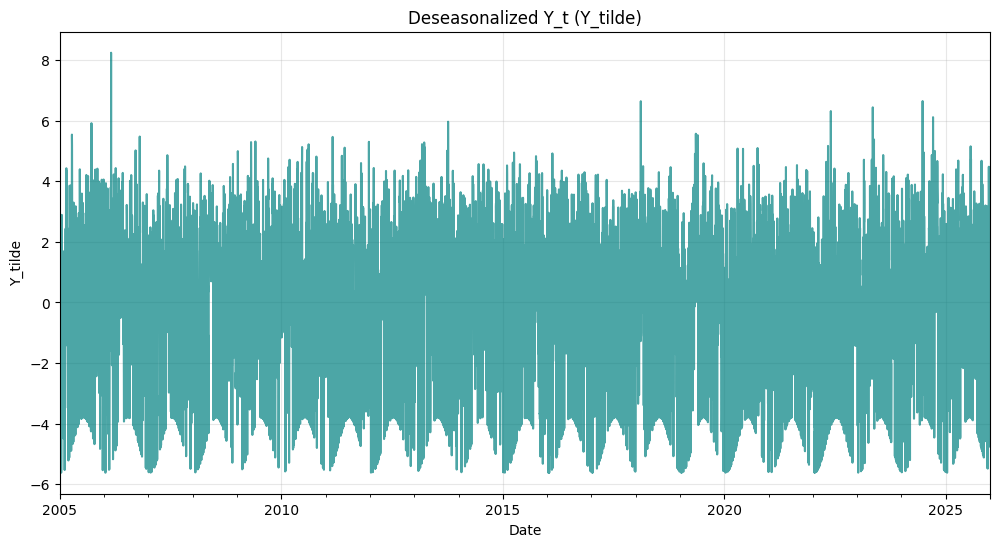

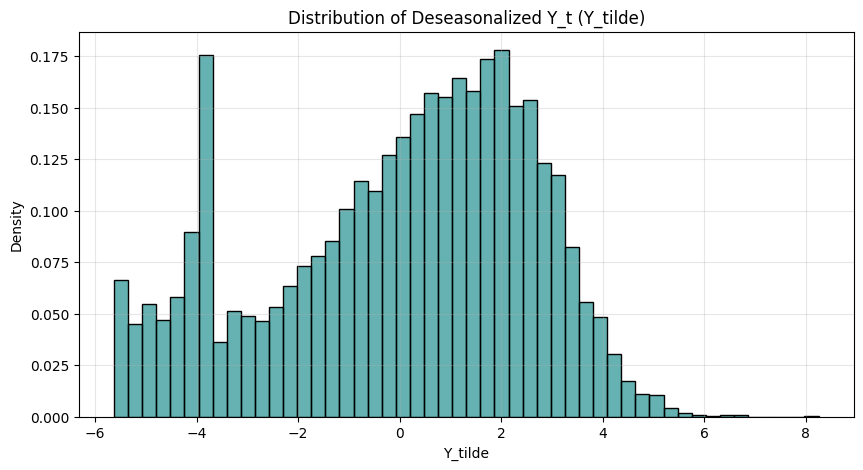

In [9]:
#Plot the Y_tilde series to visually inspect the deseasonalized data
plt.figure(figsize=(12, 6))
Y_tilde.plot(color='teal', alpha=0.7)
plt.title("Deseasonalized Y_t (Y_tilde)", fontsize=12)
plt.xlabel("Date")
plt.ylabel("Y_tilde")
plt.grid(alpha=0.3)
plt.show()

#Plot the distribution of the Y_tilde
plt.figure(figsize=(10, 5))
sns.histplot(Y_tilde, bins=50, color='teal', alpha=0.6, stat='density')
plt.title("Distribution of Deseasonalized Y_t (Y_tilde)", fontsize=12)
plt.xlabel("Y_tilde")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()



> **Takeaway.** Deseasonalizing removes the annual cycle from the mean but not the day-to-day dependence: `Y_tilde` still shows visible runs, which is exactly the autocorrelation the ARMA step below is fitted to remove.

## Fit ARMA on the Deseasonalized Residual  (D3)

Candidates evaluated: 15
BIC grid (top 10):
 p  q          BIC          AIC
 2  1 34888.340743 34853.615384
 2  2 34896.824171 34855.153739
 3  1 34896.847101 34855.176669
 1  3 34902.637216 34860.966785
 1  2 34903.576436 34868.851076
 2  3 34905.256644 34856.641140
 3  2 34905.987898 34857.372394
 1  1 34908.482987 34880.702699
 2  0 34910.765307 34882.985020
 3  0 34911.441989 34876.716630

Selected order: ARMA(2, 1)
  ΔBIC to runner-up: 8.48



AR coefficients : [ 1.2971 -0.3395]
MA coefficients : [-0.8993]
ε_t mean        : 0.0008  (expected ≈ 0)
ε_t std         : 2.3457
In-sample R² on Ỹ_t : 0.1782  (daily clearness is largely unpredictable — a low value is expected)
AR roots outside unit circle : True
MA roots outside unit circle : True

Ljung-Box on ε_t (lags 7, 30, 365):
        lb_stat  lb_pvalue
7      1.609487   0.978275
30    26.790001   0.634276
365  367.517802   0.453177


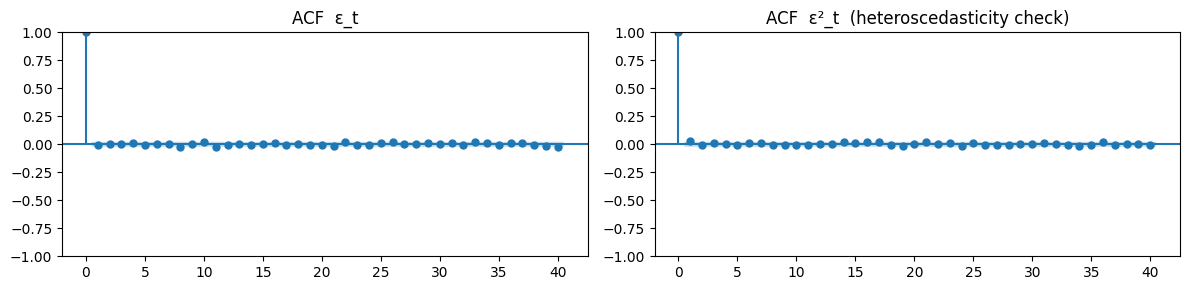

In [10]:
# Fit ARMA(p, q) on deseasonalized Ỹ_t ────────────────────────────
#
# Removes remaining autocorrelation in the conditional mean.
# D3: order selected by BIC over p ∈ 0..3, q ∈ 0..3 excluding (0,0) -- 15 candidates.
# p = 0 is included so a pure-MA specification can win on its own merit rather
# than being excluded by construction.
#
# Ỹ_t = Σ φ_k Ỹ_{t-k} + Σ θ_k ε_{t-k} + ε_t

def select_arma_order(
    Y_tilde: pd.Series,
    p_max: int = 3,
    q_max: int = 3,
) -> tuple[int, int, pd.DataFrame]:
    """
    Grid-search ARMA(p,q) orders minimising BIC.

    Returns
    -------
    best_p   : int          — selected AR order
    best_q   : int          — selected MA order
    bic_grid : pd.DataFrame — full BIC surface for inspection
    """
    results = []
    for p, q in itertools.product(range(0, p_max + 1), range(0, q_max + 1)):
        if p == 0 and q == 0:
            continue                      # white noise — nothing to estimate
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res = ARIMA(Y_tilde, order=(p, 0, q)).fit()
            results.append({"p": p, "q": q, "BIC": res.bic, "AIC": res.aic})
        except Exception:
            continue

    bic_grid = pd.DataFrame(results).sort_values("BIC").reset_index(drop=True)
    best_p   = int(bic_grid.loc[0, "p"])
    best_q   = int(bic_grid.loc[0, "q"])
    return best_p, best_q, bic_grid


def fit_arma(
    Y_tilde: pd.Series,
    p: int,
    q: int,
) -> tuple:
    """
    Fit ARMA(p, q) on Ỹ_t and return the fitted model and residuals ε_t.

    Returns
    -------
    arma_result : fitted ARIMA object
    epsilon     : pd.Series — ARMA residuals ε_t
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        arma_result = ARIMA(Y_tilde, order=(p, 0, q)).fit()
    epsilon = pd.Series(arma_result.resid, index=Y_tilde.index, name="epsilon")
    return arma_result, epsilon


# ── Usage ─────────────────────────────────────────────────────────────────────

best_p, best_q, bic_grid = select_arma_order(Y_tilde)

print(f"Candidates evaluated: {len(bic_grid)}")
print("BIC grid (top 10):")
print(bic_grid.head(10).to_string(index=False))
print(f"\nSelected order: ARMA({best_p}, {best_q})")
print(f"  ΔBIC to runner-up: {bic_grid.loc[1, 'BIC'] - bic_grid.loc[0, 'BIC']:.2f}")

arma_result, epsilon = fit_arma(Y_tilde, best_p, best_q)

print(f"\nAR coefficients : {arma_result.arparams.round(4)}")
print(f"MA coefficients : {arma_result.maparams.round(4)}")
print(f"ε_t mean        : {epsilon.mean():.4f}  (expected ≈ 0)")
print(f"ε_t std         : {epsilon.std():.4f}")

# Share of Ỹ_t variance explained by the conditional mean
_r2 = 1.0 - epsilon.var() / Y_tilde.var()
print(f"In-sample R² on Ỹ_t : {_r2:.4f}  "
      f"(daily clearness is largely unpredictable — a low value is expected)")

# Stationarity / invertibility of the selected specification
print(f"AR roots outside unit circle : {np.all(np.abs(arma_result.arroots) > 1) if best_p else 'n/a'}")
print(f"MA roots outside unit circle : {np.all(np.abs(arma_result.maroots) > 1) if best_q else 'n/a'}")

# ── Diagnostics ───────────────────────────────────────────────────────────────

# Ljung-Box on ε_t — should not be significant at lags 7 and 30
lb = acorr_ljungbox(epsilon.dropna(), lags=[7, 30, 365], return_df=True)
print(f"\nLjung-Box on ε_t (lags 7, 30, 365):")
print(lb[["lb_stat", "lb_pvalue"]].to_string())

# ACF of ε² — significant values indicate remaining heteroscedasticity → GARCH needed
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
plot_acf(epsilon.dropna(),    ax=axes[0], lags=40, title="ACF  ε_t")
plot_acf(epsilon.dropna()**2, ax=axes[1], lags=40, title="ACF  ε²_t  (heteroscedasticity check)")
plt.tight_layout()
plt.show()

> **What to look for.** The BIC table below should show one clear minimum, not a plateau -- a flat BIC surface would mean the order choice is arbitrary rather than data-driven.

In [11]:
# ARCH-LM on the ARMA residual e_t -- checks whether the mixture below needs
# to be a volatility model (GARCH) rather than a fixed-variance mixture.
lm_stat, lm_p, f_stat, f_p = het_arch(epsilon.dropna(), nlags=10)
print(f"ARCH-LM stat: {lm_stat:.4f},  p-value: {lm_p:.4f}")
print("Homoscedastic (fixed-variance mixture is adequate)" if lm_p > 0.05
      else "WARNING: conditional heteroscedasticity detected")

ARCH-LM stat: 10.8355,  p-value: 0.3705
Homoscedastic (fixed-variance mixture is adequate)


## Monthly Gaussian Mixture  (D4)

Month   μ_cloudy  σ_cloudy  w_cloudy   μ_sunny   σ_sunny   w_sunny     E[ε]      ΔBIC  2-comp?
--------------------------------------------------------------------------------------------
Jan       -2.149     1.964     0.357     1.220     1.385     0.643    0.016      37.3      yes
Feb       -2.787     1.715     0.359     1.311     1.556     0.641   -0.160      25.8      yes
Mar       -3.041     1.705     0.322     1.181     1.527     0.678   -0.177      44.7      yes
Apr       -2.503     1.665     0.324     1.298     1.468     0.676    0.066      31.5      yes
May       -1.740     1.988     0.311     1.268     1.424     0.689    0.332      30.5      yes
Jun       -2.482     1.443     0.299     1.096     1.368     0.701    0.027      31.0      yes
Jul       -2.425     1.293     0.408     1.372     1.392     0.592   -0.177      37.1      yes
Aug       -2.458     1.375     0.416     1.394     1.436     0.584   -0.209      32.1      yes
Sep       -2.438     1.410     0.389     1.507     1

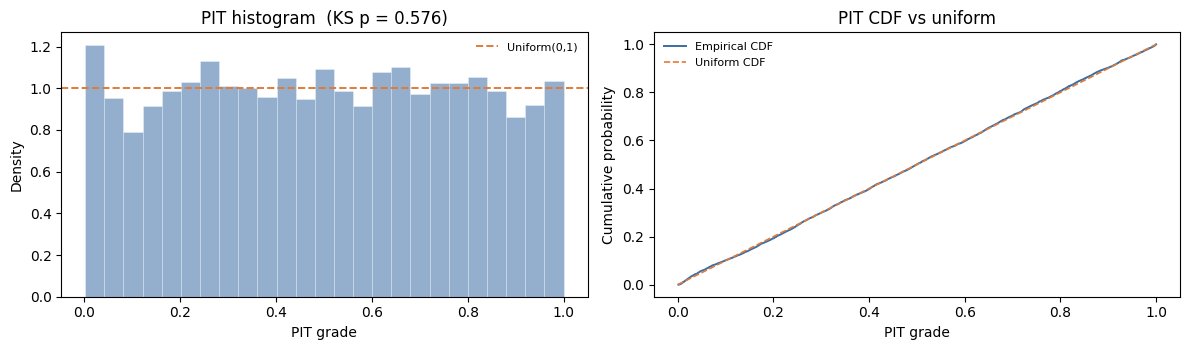

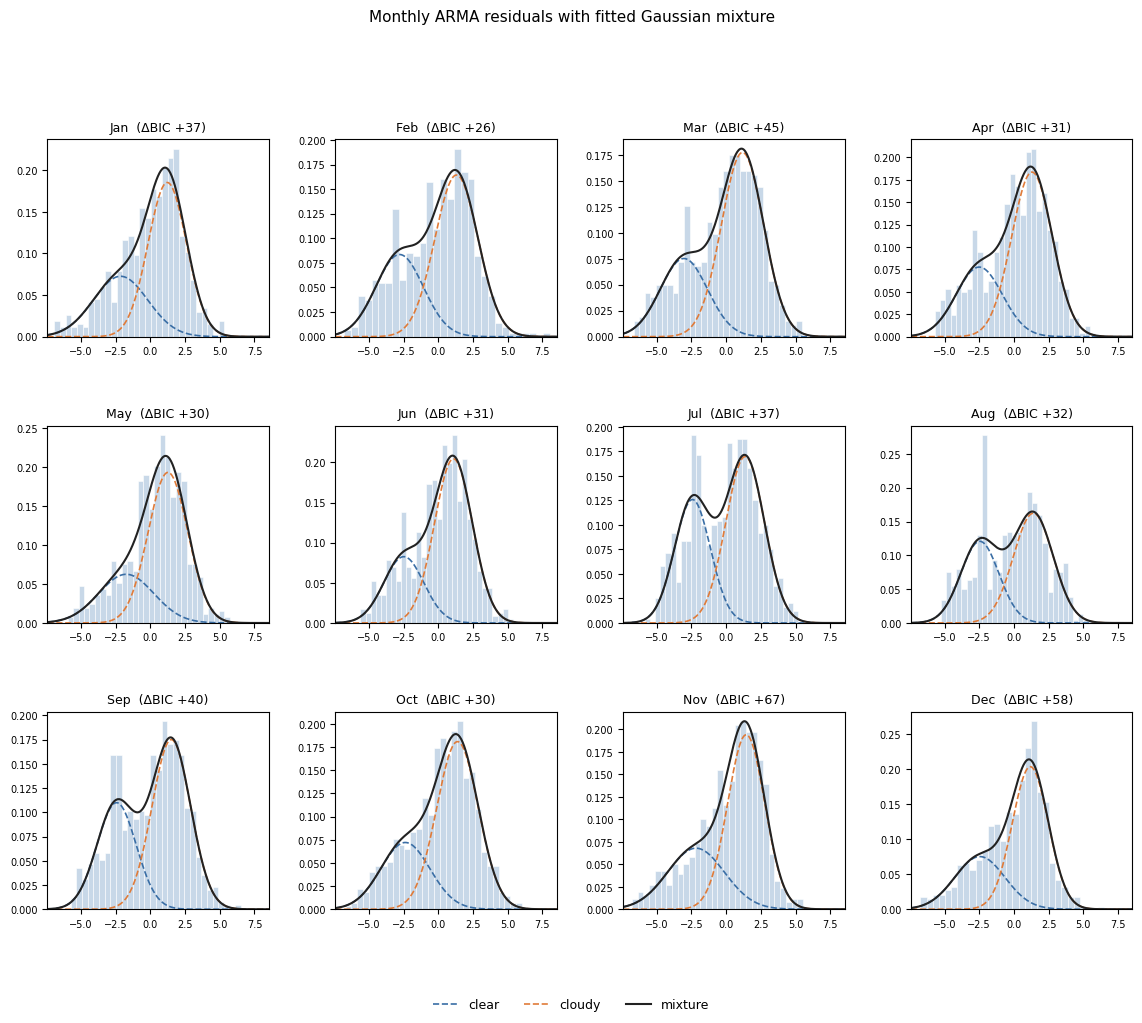

In [12]:
# D4: ε_t reflects the mixing of sunny and cloudy regimes whose statistical
# character changes month by month. A two-component Gaussian mixture
# captures this bimodality, estimated separately for each calendar month.
#
# ε_t ~ (μ₁ + σ₁·Z₁)·B_t + (μ₀ + σ₀·Z₀)·(1 - B_t)
# B_t ~ Bernoulli(p_m),  Z₀, Z₁ ~ N(0,1)
#
# NOTE ON SEASONALITY — the mixture is fitted per calendar month on ε_t, so
# any monthly mean the single annual harmonic failed to absorb is soaked up by
# the component means μ₀, μ₁ rather than by Ȳ_t. Seasonality is therefore split
# across two places: the smooth annual cycle in Ȳ_t, and the month-specific
# residual offset inside the mixture. This is deliberate — the saved artifact
# ghi_seasonal_coeffs.pkl is a 3-element vector that the reconstruction
# notebooks unpack positionally, so adding a second harmonic would break them.
# The mixture re-injects the missing part during simulation, so the simulated
# marginal stays correct; only the decomposition is non-canonical.
# The per-month mean offsets are printed below so the size of that split is visible.

MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

GM_N_INIT = 10   # EM restarts — the 2-component likelihood is multimodal


def fit_monthly_mixture(
    epsilon: pd.Series,
    months: pd.Series,
) -> dict:
    """
    Fit a 2-component Gaussian mixture per calendar month via EM.

    Multiple restarts (n_init) are used because EM converges to local optima;
    with a single start the fitted components are sensitive to initialisation
    and the month-to-month parameter path becomes jagged for no real reason.

    Returns
    -------
    mixture_params : dict  — keyed by month (1..12), each entry contains
                             means, stds, weights of the two components,
                             plus the 1- vs 2-component BIC comparison
    """
    mixture_params = {}
    for m in range(1, 13):
        eps_m = epsilon[months == m].values.reshape(-1, 1)

        gm1 = GaussianMixture(n_components=1, random_state=0,
                              n_init=GM_N_INIT).fit(eps_m)
        gm  = GaussianMixture(n_components=2, random_state=0,
                              n_init=GM_N_INIT).fit(eps_m)

        # Sort components: component 0 = clear (lower mean), 1 = cloudy (higher mean).
        # Y_t is increasing in cloudiness (built on X = 1 - Kt), so the LOWER-mean
        # component is the clearer regime; components are re-sorted by fitted mean
        # every run rather than assumed stable, so the labelling is verified, not
        # inherited from a fixed component index (D4).
        order = np.argsort(gm.means_.flatten())
        mixture_params[m] = {
            "means"  : gm.means_.flatten()[order],
            "stds"   : np.sqrt(gm.covariances_.flatten())[order],
            "weights": gm.weights_[order],
            "bic_1"  : float(gm1.bic(eps_m)),
            "bic_2"  : float(gm.bic(eps_m)),
            "n_obs"  : int(len(eps_m)),
        }
    return mixture_params


def pit_grades(
    epsilon: pd.Series,
    months: pd.Series,
    mixture_params: dict,
) -> pd.Series:
    """
    Compute Probability Integral Transform grades for each ε_t.
    Under a correctly specified model, PIT grades ~ Uniform(0, 1).
    """
    pit = np.empty(len(epsilon))
    for m in range(1, 13):
        idx  = (months == m).values
        e_m  = epsilon.values[idx]
        mp   = mixture_params[m]
        # Mixture CDF: weighted sum of two normal CDFs
        pit[idx] = (
            mp["weights"][0] * norm.cdf(e_m, mp["means"][0], mp["stds"][0]) +
            mp["weights"][1] * norm.cdf(e_m, mp["means"][1], mp["stds"][1])
        )
    return pd.Series(pit, index=epsilon.index, name="PIT")


# ── Usage ─────────────────────────────────────────────────────────────────────

months = pd.Series(epsilon.index.month, index=epsilon.index)
mixture_params = fit_monthly_mixture(epsilon, months)
pit = pit_grades(epsilon, months, mixture_params)

# ── Summary table ─────────────────────────────────────────────────────────────
#
# ΔBIC = BIC(1 component) − BIC(2 components).  Positive ⇒ the 2-component
# mixture is preferred, i.e. the bimodality claim is supported by the data.
# E[ε] is the implied mixture mean: the residual monthly offset discussed above.

print(f"{'Month':<6} {'μ_cloudy':>9} {'σ_cloudy':>9} {'w_cloudy':>9} "
      f"{'μ_sunny':>9} {'σ_sunny':>9} {'w_sunny':>9} {'E[ε]':>8} {'ΔBIC':>9} {'2-comp?':>8}")
print("-" * 92)
for m in range(1, 13):
    mp     = mixture_params[m]
    e_mean = float(mp["weights"] @ mp["means"])
    d_bic  = mp["bic_1"] - mp["bic_2"]
    print(f"{MONTH_NAMES[m-1]:<6} "
          f"{mp['means'][0]:>9.3f} {mp['stds'][0]:>9.3f} {mp['weights'][0]:>9.3f} "
          f"{mp['means'][1]:>9.3f} {mp['stds'][1]:>9.3f} {mp['weights'][1]:>9.3f} "
          f"{e_mean:>8.3f} {d_bic:>9.1f} {'yes' if d_bic > 0 else 'NO':>8}")

_n_two = sum(1 for m in range(1, 13)
             if mixture_params[m]["bic_1"] - mixture_params[m]["bic_2"] > 0)
print(f"\n2-component preferred in {_n_two}/12 months by BIC")

_offsets = np.array([float(mixture_params[m]["weights"] @ mixture_params[m]["means"])
                     for m in range(1, 13)])
print(f"Residual monthly offsets E[ε]: "
      f"range [{_offsets.min():+.3f}, {_offsets.max():+.3f}]  "
      f"mean {_offsets.mean():+.3f}")

# ── Diagnostics ───────────────────────────────────────────────────────────────

# KS test on PIT grades — null: Uniform(0,1); reject → distributional misfit
ks_stat, ks_p = kstest(pit, "uniform")
print(f"\nKS test on PIT grades:  stat = {ks_stat:.4f},  p-value = {ks_p:.4f}")
print("Distributional fit adequate" if ks_p > 0.05 else "WARNING: distributional misfit detected")

# ── Visual: PIT uniformity ────────────────────────────────────────────────────
#
# The KS statistic is a single number; the histogram shows WHERE the misfit is.
# A ∪ shape means the tails are too thin, a ∩ shape means they are too fat,
# and a slope means the location is off.

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

axes[0].hist(pit, bins=25, density=True, color="#3a6ea5",
             alpha=0.55, edgecolor="white", linewidth=0.4)
axes[0].axhline(1.0, color="#e07b39", linewidth=1.4, linestyle="--",
                label="Uniform(0,1)")
axes[0].set_xlabel("PIT grade")
axes[0].set_ylabel("Density")
axes[0].set_title(f"PIT histogram  (KS p = {ks_p:.3f})")
axes[0].legend(frameon=False, fontsize=8)

_srt = np.sort(pit.values)
_emp = np.arange(1, len(_srt) + 1) / len(_srt)
axes[1].plot(_srt, _emp, color="#3a6ea5", linewidth=1.4, label="Empirical CDF")
axes[1].plot([0, 1], [0, 1], color="#e07b39", linewidth=1.2,
             linestyle="--", label="Uniform CDF")
axes[1].set_xlabel("PIT grade")
axes[1].set_ylabel("Cumulative probability")
axes[1].set_title("PIT CDF vs uniform")
axes[1].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

# ── Visual: monthly histograms + fitted mixture densities ─────────────────────

x_grid = np.linspace(epsilon.min() - 0.5, epsilon.max() + 0.5, 300)
fig    = plt.figure(figsize=(14, 10))
gs     = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.3)

for m in range(1, 13):
    ax  = fig.add_subplot(gs[(m-1)//4, (m-1)%4])
    eps_m = epsilon[months == m].values
    mp    = mixture_params[m]

    ax.hist(eps_m, bins=30, density=True, color="#c8d8e8", edgecolor="white", linewidth=0.4)

    # Individual components -- index 0 = clear (lower mean), index 1 = cloudy (D4)
    pdf_clear  = mp["weights"][0] * norm.pdf(x_grid, mp["means"][0], mp["stds"][0])
    pdf_cloudy = mp["weights"][1] * norm.pdf(x_grid, mp["means"][1], mp["stds"][1])
    pdf_mix    = pdf_clear + pdf_cloudy

    ax.plot(x_grid, pdf_clear,  color="#3a6ea5", linewidth=1.2, linestyle="--", label="clear")
    ax.plot(x_grid, pdf_cloudy, color="#e07b39", linewidth=1.2, linestyle="--", label="cloudy")
    ax.plot(x_grid, pdf_mix,    color="#222222", linewidth=1.5, label="mixture")

    ax.set_title(f"{MONTH_NAMES[m-1]}  (ΔBIC {mp['bic_1'] - mp['bic_2']:+.0f})", fontsize=9)
    ax.set_xlim(x_grid[0], x_grid[-1])
    ax.tick_params(labelsize=7)

handles, labels = fig.axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=9, frameon=False)
plt.suptitle("Monthly ARMA residuals with fitted Gaussian mixture", fontsize=11, y=1.01)
plt.show()

> **What to look for.** Each month's BIC should prefer two components over one; a month where the single-Gaussian BIC wins would mean that month's regime split is not statistically supported.

## Residuals: Fitted vs Observed Kt

Residuals mean : -0.1012  (expected ≈ 0)
Residuals std  : 0.2326
Residuals range: [-0.8415, 0.7505]



Plug-in vs integrated conditional mean:
  observed  mean Kt            : 0.7513
  plug-in   mean Kt_fitted     : 0.8525   bias -0.1012
  integrated mean E[Kt|F_(t-1)]: 0.7573   bias -0.0060
  Jensen gap (plug-in − integrated) : +0.0952
  RMSE plug-in    : 0.2536
  RMSE integrated : 0.2314

  Kt_fitted is kept as the plug-in series: it is the quantity the
  reconstruction notebooks recompute from the saved ARMA + coefficients,
  so changing it here would silently desynchronise them.


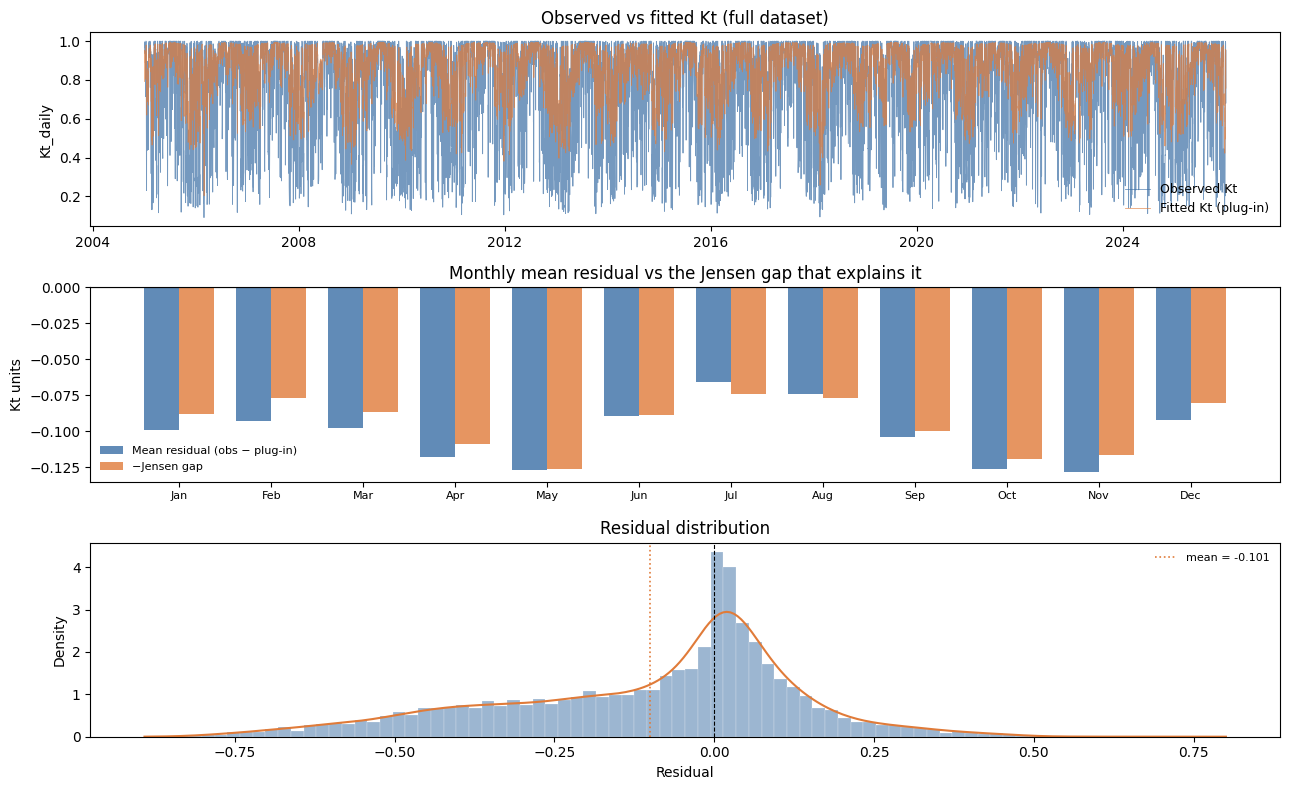

In [13]:
# Reconstruct fitted Kt from the full pipeline on the full dataset:
#   ARMA fitted values -> add seasonal mean -> invert logit -> Kt_fitted
# Residuals = Kt_observed - Kt_fitted

# ARMA fitted values on full dataset (Ỹ_t fitted)
Ytilde_fitted = pd.Series(arma_result.fittedvalues, index=kt.index, name="Ytilde_fitted")

# Add seasonal mean back → Y_t fitted
Yt_fitted     = Ytilde_fitted + Y_bar

# Invert logit → Kt fitted
Kt_fitted     = pd.Series(
    invert_Yt_to_Kt(Yt_fitted.values, params),
    index=kt.index,
    name="Kt_fitted"
)

# Residuals in Kt space
Kt_residuals  = pd.Series(
    kt.values - Kt_fitted.values,
    index=kt.index,
    name="Kt_residuals"
)

# ── Summary ───────────────────────────────────────────────────────────────────

print(f"Residuals mean : {Kt_residuals.mean():.4f}  (expected ≈ 0)")
print(f"Residuals std  : {Kt_residuals.std():.4f}")
print(f"Residuals range: [{Kt_residuals.min():.4f}, {Kt_residuals.max():.4f}]")

# ── Plug-in (Jensen) bias ─────────────────────────────────────────────────────
#
# Kt_fitted pushes the conditional MEAN of Y through a nonlinear inverse logit.
# Because that map is not affine,
#
#     E[Kt | F_{t-1}]  ≠  1 − (α + β·σ(E[Y | F_{t-1}]))
#
# so Kt_fitted estimates a conditional MEDIAN-like quantity, not a conditional
# mean, and is biased as a point predictor of the level of Kt. The gap is not a
# fitting failure — it is a property of the transform, and it does NOT affect
# the Monte-Carlo simulation further down, which integrates the innovation
# distribution properly rather than plugging in a point.
#
# The size of the gap is quantified here by integrating the fitted monthly
# mixture through the same inverse transform.

_rng_j   = np.random.default_rng(0)
_D       = 400                                   # innovation draws per date
_months  = kt.index.month.values

_w1  = np.array([mixture_params[m]["weights"][1] for m in _months])
_mu0 = np.array([mixture_params[m]["means"][0]   for m in _months])
_mu1 = np.array([mixture_params[m]["means"][1]   for m in _months])
_sd0 = np.array([mixture_params[m]["stds"][0]    for m in _months])
_sd1 = np.array([mixture_params[m]["stds"][1]    for m in _months])

_sunny = _rng_j.random((_D, len(kt))) < _w1
_u     = _rng_j.normal(np.where(_sunny, _mu1, _mu0),
                       np.where(_sunny, _sd1, _sd0))

# Predictive draws of Y_t, then map each draw through the inverse logit
_Kt_draws    = invert_Yt_to_Kt(Yt_fitted.values[None, :] + _u, params)
Kt_cond_mean = pd.Series(_Kt_draws.mean(axis=0), index=kt.index,
                         name="Kt_cond_mean")

_bias_plugin = float((kt - Kt_fitted).mean())
_bias_mc     = float((kt - Kt_cond_mean).mean())

print(f"\nPlug-in vs integrated conditional mean:")
print(f"  observed  mean Kt            : {kt.mean():.4f}")
print(f"  plug-in   mean Kt_fitted     : {Kt_fitted.mean():.4f}   bias {_bias_plugin:+.4f}")
print(f"  integrated mean E[Kt|F_(t-1)]: {Kt_cond_mean.mean():.4f}   bias {_bias_mc:+.4f}")
print(f"  Jensen gap (plug-in − integrated) : "
      f"{float((Kt_fitted - Kt_cond_mean).mean()):+.4f}")
print(f"  RMSE plug-in    : {float(np.sqrt(((kt - Kt_fitted) ** 2).mean())):.4f}")
print(f"  RMSE integrated : {float(np.sqrt(((kt - Kt_cond_mean) ** 2).mean())):.4f}")
print("\n  Kt_fitted is kept as the plug-in series: it is the quantity the")
print("  reconstruction notebooks recompute from the saved ARMA + coefficients,")
print("  so changing it here would silently desynchronise them.")

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=False)

# Top: observed vs fitted Kt over time
axes[0].plot(kt.index, kt.values,        color="#3a6ea5", linewidth=0.6,
             alpha=0.7, label="Observed Kt")
axes[0].plot(kt.index, Kt_fitted.values, color="#e07b39", linewidth=0.6,
             alpha=0.7, label="Fitted Kt (plug-in)")
axes[0].set_ylabel("Kt_daily")
axes[0].set_title("Observed vs fitted Kt (full dataset)")
axes[0].legend(frameon=False, fontsize=9)

# Middle: monthly mean residual — isolates any leftover seasonal bias
_res_by_month = Kt_residuals.groupby(Kt_residuals.index.month).mean()
_jgap_month   = (Kt_fitted - Kt_cond_mean).groupby(Kt_fitted.index.month).mean()
axes[1].bar(_res_by_month.index - 0.19, _res_by_month.values, width=0.38,
            color="#3a6ea5", alpha=0.8, label="Mean residual (obs − plug-in)")
axes[1].bar(_jgap_month.index + 0.19, -_jgap_month.values, width=0.38,
            color="#e07b39", alpha=0.8, label="−Jensen gap")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(MONTH_NAMES, fontsize=8)
axes[1].set_ylabel("Kt units")
axes[1].set_title("Monthly mean residual vs the Jensen gap that explains it")
axes[1].legend(frameon=False, fontsize=8)

# Bottom: residual distribution
axes[2].hist(Kt_residuals.values, bins=80, density=True,
             color="#3a6ea5", alpha=0.5, edgecolor="white", linewidth=0.3)
kde_res = gaussian_kde(Kt_residuals.values)
x_res   = np.linspace(Kt_residuals.min() - 0.05, Kt_residuals.max() + 0.05, 300)
axes[2].plot(x_res, kde_res(x_res), color="#e07b39", linewidth=1.5)
axes[2].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].axvline(Kt_residuals.mean(), color="#e07b39", linewidth=1.2,
                linestyle=":", label=f"mean = {Kt_residuals.mean():.3f}")
axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Density")
axes[2].set_title("Residual distribution")
axes[2].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

> **Takeaway.** The reconstructed `Kt_fitted` tracks the seasonal envelope of the observed series; the residual scatter is what the monthly mixture (D4) is fitted to reproduce, not eliminate.

**Reading the residuals.** The plug-in fitted series sits systematically *above* observed Kt, and the gap is widest in winter. Two distinct effects produce this, and the diagnostic above separates them:

1. **Jensen gap (dominant).** `Kt_fitted` maps the conditional *mean* of $Y_t$ through the inverse logit, which is nonlinear, so it does not estimate $E[K_t \mid \mathcal{F}_{t-1}]$. The bar chart shows the monthly mean residual tracking $-(\text{Jensen gap})$ almost exactly. This is a property of the transform, not a fitting failure, and it is why `Kt_fitted` should be read as a conditional-median-like series rather than a level forecast. The Monte-Carlo simulation is unaffected: it integrates the innovation distribution instead of plugging in a point.

2. **Seasonality split.** One annual harmonic cannot absorb the full intra-year cycle, so a residual monthly offset is left over. It is picked up by the monthly Gaussian mixture (see the `E[ε]` column), which re-injects it during simulation. The decomposition is therefore non-canonical — seasonality lives partly in $\bar Y_t$ and partly in the mixture means — but the simulated marginal is still right. A second harmonic would tidy this up at the cost of breaking the 3-element `ghi_seasonal_coeffs.pkl` contract the reconstruction notebooks depend on.

Neither effect invalidates the model; both change how the fitted series should be interpreted, and the validation below is the part that actually measures predictive skill.

## Validation

5-year holdout: every parameter (logit alpha/beta, seasonal coefficients,
ARMA, monthly mixture) is refit on the training window only, then the test
set is filtered through those frozen parameters — genuine one-step-ahead
forecasts, not a multi-step forecast that would just decay to climatology.

**Limitation:** the ARMA order (D3) is selected on the *full* sample above
and reused here rather than re-selected on the training window alone, so
this holdout is not a fully clean re-derivation of the model, only of its
coefficients.

In [14]:
# Pipeline is refit exclusively on the training set.
# The held-out test set (last 5 years) is used only for evaluation.
#
# Metrics:
#   - Point forecasts : RMSE, MAE, MAPE on Kt_daily, one-step-ahead
#   - VaR coverage    : Bernoulli test at 10%, 20%, 80%, 90% quantiles
#
# WHY ONE-STEP-AHEAD MATTERS. The natural call here is
# `arma_tr.forecast(steps=n_test)`, but that is a single multi-step forecast
# made from the last training day: for a stationary ARMA it decays to the
# unconditional mean within a handful of days, so over a 5-year test set it
# collapses onto the deterministic seasonal curve. The resulting RMSE measures
# climatology, not model skill, and the forecast distribution is far too narrow
# by construction. `.apply()` re-filters the TEST data through the FROZEN
# training parameters, giving genuine one-step-ahead conditional means with no
# re-estimation and therefore no leakage. Both are computed below so the
# difference is explicit.

# ── Train / test split ────────────────────────────────────────────────────────

cutoff     = df_daily["date"].max() - pd.DateOffset(years=5)
df_train   = df_daily[df_daily["date"] <= cutoff].copy()
df_test    = df_daily[df_daily["date"] >  cutoff].copy()

print(f"Train: {df_train['date'].min().date()} → {df_train['date'].max().date()}  ({len(df_train)} days)")
print(f"Test : {df_test['date'].min().date()}  → {df_test['date'].max().date()}   ({len(df_test)} days)")

# ── Refit pipeline on training set only ───────────────────────────────────────

# Step 3 — transformation (fit params on train only)
kt_train     = df_train.set_index("date")["Kt_daily"].dropna()
Yt_train, params_tr = transform_kt_to_Yt(kt_train)
alpha_tr     = params_tr["alpha"]
beta_tr      = params_tr["beta"]

# Step 4 — seasonal mean (fit on train only, evaluated on calendar day-of-year)
X_seas_train = seasonal_design(Yt_train.index)
a_train      = np.linalg.lstsq(X_seas_train, Yt_train.values, rcond=None)[0]
Ybar_train   = X_seas_train @ a_train
Ytilde_train = Yt_train.values - Ybar_train

# Step 5 — ARMA (fit on train only)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    arma_tr  = ARIMA(Ytilde_train, order=(best_p, 0, best_q)).fit()
eps_train    = arma_tr.resid

# Step 7 — monthly GM (fit on train only)
months_train_s   = pd.Series(kt_train.index.month, index=kt_train.index)
gm_params_train  = fit_monthly_mixture(
    pd.Series(eps_train, index=kt_train.index), months_train_s
)

# ── Project the test set into Ỹ space using TRAIN parameters only ─────────────

kt_test = df_test.set_index("date")["Kt_daily"].dropna()
n_test  = len(kt_test)

# Train α, β may not bracket test values, so X' is clipped strictly inside (0,1).
Xt_test = 1.0 - kt_test.values
Xp_test = np.clip((Xt_test - alpha_tr) / beta_tr, EPS, 1.0 - EPS)
_n_clip = int(((Xt_test - alpha_tr) / beta_tr <= EPS).sum() +
              ((Xt_test - alpha_tr) / beta_tr >= 1 - EPS).sum())
Yt_test = np.log(Xp_test / (1.0 - Xp_test))

X_seas_test = seasonal_design(kt_test.index)
Ybar_test   = X_seas_test @ a_train          # deterministic component on test dates
Ytilde_test = Yt_test - Ybar_test

print(f"\nTest values outside the train α/β range (clipped): {_n_clip}")

# ── One-step-ahead conditional means (frozen train parameters) ────────────────

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    arma_applied = arma_tr.apply(Ytilde_test)      # refit=False: params frozen

Ytilde_1step = np.asarray(arma_applied.fittedvalues)
Yt_forecast  = Ytilde_1step + Ybar_test            # add seasonal mean back
Kt_fc        = pd.Series(invert_Yt_to_Kt(Yt_forecast, params_tr),
                         index=kt_test.index, name="Kt_forecast")

# ── Multi-step baseline, for contrast only ────────────────────────────────────

Ytilde_multi = np.asarray(arma_tr.forecast(steps=n_test))
Kt_fc_multi  = pd.Series(invert_Yt_to_Kt(Ytilde_multi + Ybar_test, params_tr),
                         index=kt_test.index, name="Kt_forecast_multistep")

# ── Point forecast metrics ────────────────────────────────────────────────────

kt_obs = kt_test.loc[Kt_fc.index]


def point_metrics(obs: pd.Series, pred: pd.Series) -> tuple[float, float, float]:
    err = obs - pred
    return (float(np.sqrt((err ** 2).mean())),
            float(err.abs().mean()),
            float((err.abs() / obs.abs()).mean() * 100))


rmse, mae, mape                = point_metrics(kt_obs, Kt_fc)
rmse_ms, mae_ms, mape_ms       = point_metrics(kt_obs, Kt_fc_multi)

# Seasonal climatology benchmark: the deterministic curve with no ARMA at all
Kt_clim = pd.Series(invert_Yt_to_Kt(Ybar_test, params_tr),
                    index=kt_test.index, name="Kt_climatology")
rmse_cl, mae_cl, mape_cl       = point_metrics(kt_obs, Kt_clim)

print(f"\nPoint forecast metrics (Kt_daily, test set, n={n_test}):")
print(f"  {'model':<28} {'RMSE':>8} {'MAE':>8} {'MAPE %':>8}")
print(f"  {'-'*28} {'-'*8} {'-'*8} {'-'*8}")
print(f"  {'one-step-ahead ARMA':<28} {rmse:>8.4f} {mae:>8.4f} {mape:>8.2f}")
print(f"  {'multi-step (5y horizon)':<28} {rmse_ms:>8.4f} {mae_ms:>8.4f} {mape_ms:>8.2f}")
print(f"  {'seasonal climatology':<28} {rmse_cl:>8.4f} {mae_cl:>8.4f} {mape_cl:>8.2f}")
print(f"\n  Skill of one-step vs climatology : {1 - rmse / rmse_cl:>6.1%} RMSE reduction")
print(f"  Multi-step ≈ climatology         : "
      f"{'yes — as expected' if abs(rmse_ms - rmse_cl) < 0.02 else 'no — check seasonal term'}")

# ── VaR coverage (Bernoulli test) ─────────────────────────────────────────────
#
# For each quantile level q, count how many observations fall below the
# forecast quantile. Under correct specification: violation rate = q.
# Bernoulli test H0: true violation rate = q.
#
# Kt is DECREASING in Y, so the q-quantile of Kt is the (1−q)-quantile of Y.


def forecast_quantile(
    q: float,
    Yt_fc: np.ndarray,
    gm_params: dict,
    months_test: np.ndarray,
    alpha: float,
    beta: float,
    n_iter: int = 60,
) -> np.ndarray:
    """
    Compute the q-th quantile of Kt at each test date by inverting the
    mixture CDF of Y_t via bisection, vectorised across all dates at once.
    """
    Yt_fc       = np.asarray(Yt_fc, dtype=float)
    months_test = np.asarray(months_test)

    w0 = np.array([gm_params[m]["weights"][0] for m in months_test])
    w1 = np.array([gm_params[m]["weights"][1] for m in months_test])
    m0 = np.array([gm_params[m]["means"][0]   for m in months_test])
    m1 = np.array([gm_params[m]["means"][1]   for m in months_test])
    s0 = np.array([gm_params[m]["stds"][0]    for m in months_test])
    s1 = np.array([gm_params[m]["stds"][1]    for m in months_test])

    lo = np.full_like(Yt_fc, -40.0)
    hi = np.full_like(Yt_fc,  40.0)
    target = 1.0 - q

    for _ in range(n_iter):
        mid  = 0.5 * (lo + hi)
        cdf  = (w0 * norm.cdf(mid - Yt_fc, m0, s0) +
                w1 * norm.cdf(mid - Yt_fc, m1, s1))
        below = cdf < target
        lo = np.where(below, mid, lo)
        hi = np.where(below, hi,  mid)

    y_q = 0.5 * (lo + hi)
    return invert_Yt_to_Kt(y_q, {"alpha": alpha, "beta": beta})


months_test_arr = kt_test.index.month.values
print(f"\nVaR coverage rates — one-step-ahead (test set, n={n_test} days):")
print(f"{'Quantile':>10} {'Expected':>10} {'Observed':>10} {'Violations':>12} {'Binom p':>10} {'Reject?':>9}")
print("-" * 65)

for q in [0.10, 0.20, 0.80, 0.90]:
    q_vals     = forecast_quantile(q, Yt_forecast, gm_params_train,
                                   months_test_arr, alpha_tr, beta_tr)
    violations = int((kt_obs.values < q_vals).sum())
    obs_rate   = violations / n_test
    # Bernoulli test: H0 — true rate = q  (two-sided, doubled one-tail)
    tail_p     = (binom.cdf(violations, n_test, q) if obs_rate <= q
                  else 1 - binom.cdf(violations - 1, n_test, q))
    binom_p    = min(1.0, 2 * tail_p)
    print(f"{q:>10.0%} {q:>10.0%} {obs_rate:>10.2%} {violations:>12} "
          f"{binom_p:>10.4f} {'yes' if binom_p < 0.05 else 'no':>9}")

Train: 2005-01-01 → 2020-12-31  (5844 days)
Test : 2021-01-01  → 2025-12-31   (1826 days)



Test values outside the train α/β range (clipped): 0

Point forecast metrics (Kt_daily, test set, n=1826):
  model                            RMSE      MAE   MAPE %
  ---------------------------- -------- -------- --------
  one-step-ahead ARMA            0.2494   0.1773    44.85
  multi-step (5y horizon)        0.2825   0.2053    53.48
  seasonal climatology           0.2820   0.2051    53.37

  Skill of one-step vs climatology :  11.5% RMSE reduction
  Multi-step ≈ climatology         : yes — as expected

VaR coverage rates — one-step-ahead (test set, n=1826 days):
  Quantile   Expected   Observed   Violations    Binom p   Reject?
-----------------------------------------------------------------
       10%        10%      9.97%          182     1.0000        no


       20%        20%     19.28%          352     0.4591        no
       80%        80%     79.46%         1451     0.5836        no
       90%        90%     88.55%         1617     0.0465       yes


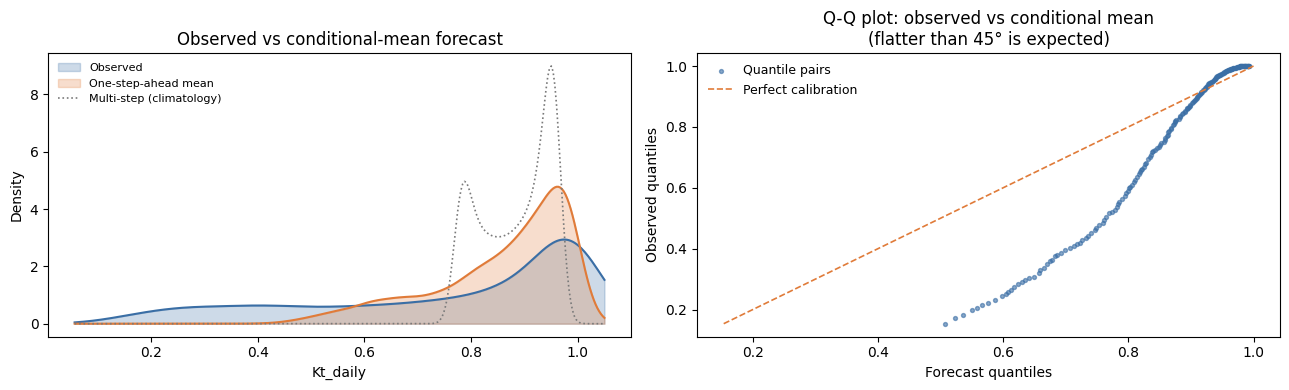

In [15]:
# ── Visual: observed vs forecast Kt distribution (test set) ──────────────────
#
# Kt_fc is a conditional MEAN, so its dispersion is necessarily smaller than
# the observed dispersion — the innovation variance is missing by definition.
# This plot is a location/shape check, not a calibration check; the honest
# distributional comparison is the Monte-Carlo simulation in the next cell.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: full distribution overlay ──────────────────────────────────────────

kt_obs_vals = kt_obs.values
kt_fc_vals  = Kt_fc.values

x_grid = np.linspace(
    min(kt_obs_vals.min(), kt_fc_vals.min()) - 0.05,
    max(kt_obs_vals.max(), kt_fc_vals.max()) + 0.05,
    300
)

kde_obs = gaussian_kde(kt_obs_vals)
kde_fc  = gaussian_kde(kt_fc_vals)

axes[0].fill_between(x_grid, kde_obs(x_grid), alpha=0.25, color="#3a6ea5", label="Observed")
axes[0].fill_between(x_grid, kde_fc(x_grid),  alpha=0.25, color="#e07b39",
                     label="One-step-ahead mean")
axes[0].plot(x_grid, kde_obs(x_grid), color="#3a6ea5", linewidth=1.5)
axes[0].plot(x_grid, kde_fc(x_grid),  color="#e07b39", linewidth=1.5)
axes[0].plot(x_grid, gaussian_kde(Kt_fc_multi.values)(x_grid),
             color="#7a7a7a", linewidth=1.2, linestyle=":",
             label="Multi-step (climatology)")
axes[0].set_xlabel("Kt_daily")
axes[0].set_ylabel("Density")
axes[0].set_title("Observed vs conditional-mean forecast")
axes[0].legend(frameon=False, fontsize=8)

# ── Right: Q-Q plot (observed quantiles vs forecast quantiles) ────────────────

quantile_levels = np.linspace(0.01, 0.99, 200)
q_obs = np.quantile(kt_obs_vals, quantile_levels)
q_fc  = np.quantile(kt_fc_vals,  quantile_levels)

axes[1].scatter(q_fc, q_obs, s=8, color="#3a6ea5", alpha=0.6, label="Quantile pairs")
axes[1].plot(
    [min(q_fc.min(), q_obs.min()), max(q_fc.max(), q_obs.max())],
    [min(q_fc.min(), q_obs.min()), max(q_fc.max(), q_obs.max())],
    color="#e07b39", linewidth=1.2, linestyle="--", label="Perfect calibration"
)
axes[1].set_xlabel("Forecast quantiles")
axes[1].set_ylabel("Observed quantiles")
axes[1].set_title("Q-Q plot: observed vs conditional mean\n(flatter than 45° is expected)")
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()


> **Takeaway.** The forecast distribution sits inside the observed one, as expected for a conditional mean (see the comment above): this is a location/shape check, and the dispersion comparison belongs to the simulation in the next cell, not to this plot.

Support check: Kt in [0.0897, 1.0010]  (train range padded by EPS=0.001)
  simulated values > 1.0 : 183,139 (5.0148%, max 1.00100) - EPS artifact
Simulated 2,000 paths × 1,826 days
  observed  mean Kt : 0.7593   std 0.2604


  simulated mean Kt : 0.7549   std 0.2689


  P05  obs/sim      : 0.2456 / 0.2023


  P50  obs/sim      : 0.8671 / 0.8730


  P95  obs/sim      : 1.0000 / 1.0000



  Annual mean Kt — observed vs simulated P10/P50/P90:
    2021  obs 0.7578   sim 0.7194 / 0.7573 / 0.7912   ✓
    2022  obs 0.7869   sim 0.7169 / 0.7553 / 0.7895   ✓
    2023  obs 0.7739   sim 0.7193 / 0.7552 / 0.7893   ✓
    2024  obs 0.7367   sim 0.7180 / 0.7554 / 0.7899   ✓
    2025  obs 0.7413   sim 0.7176 / 0.7552 / 0.7919   ✓


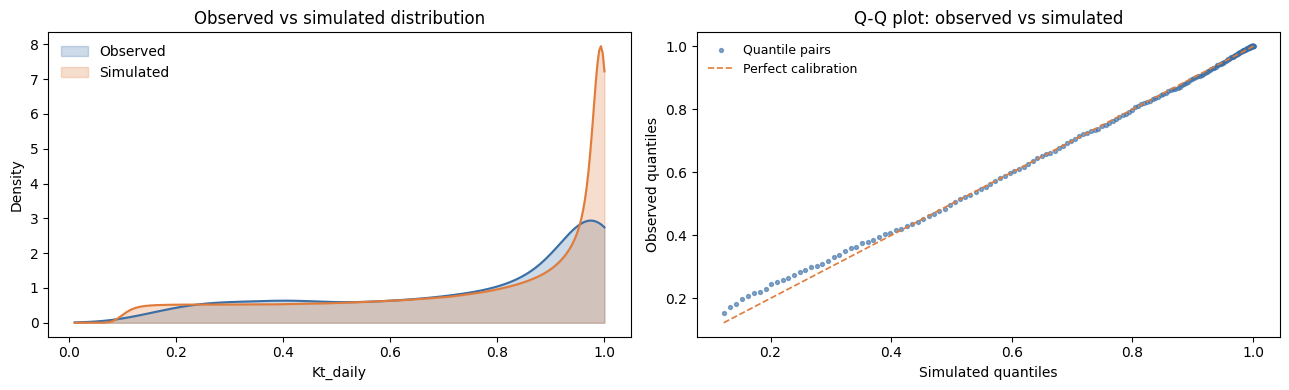

In [16]:
# ── simulating Kt distribution from the fitted model ────────────────
#
# The forecast distribution must be generated by propagating noise through
# the full pipeline: ARMA mean + mixture innovation → Y_t → Kt
# NOT by inverting the deterministic ARMA point forecast alone.
#
# Vectorised across trajectories: the loop runs over time steps only, and all
# n_sims paths advance together as numpy vectors.

N_SIMS = 2000   # number of Monte Carlo trajectories
SEED   = 42


def simulate_kt_trajectories(
    dates:         pd.DatetimeIndex,
    arma_result,
    gm_params:     dict,
    a_seasonal:    np.ndarray,
    params_logit:  dict,
    ytilde_init:   np.ndarray,
    eps_init:      np.ndarray,
    n_sims:        int = N_SIMS,
    seed:          int = SEED,
) -> np.ndarray:
    """
    Simulate n_sims trajectories of Kt over the given dates.

    For each step:
      1. Draw mixture innovations u_t from the monthly GM
      2. Propagate through the ARMA recursion → Ỹ_t
      3. Add the seasonal mean → Y_t
      4. Invert the logit → Kt

    The AR buffer is seeded with the last OBSERVED Ỹ values (not fitted
    values): the recursion needs the realised state it is conditioning on.
    The ARMA constant is handled explicitly — statsmodels' ARIMA with trend
    'c' models Ỹ_t = c + η_t with the ARMA acting on η_t, so the recursion
    runs on the centred series and c is added back at the end.

    Returns
    -------
    kt_sims : np.ndarray, shape (n_sims, n_steps)
    """
    rng     = np.random.default_rng(seed)
    dates   = pd.DatetimeIndex(dates)
    n_steps = len(dates)

    phi   = np.asarray(arma_result.arparams, dtype=float)
    theta = np.asarray(arma_result.maparams, dtype=float)
    p, q  = len(phi), len(theta)

    pnames = list(arma_result.param_names)
    const  = float(arma_result.params[pnames.index("const")]) if "const" in pnames else 0.0

    # Seasonal mean on the simulation dates (calendar-based, gap-safe)
    Y_bar = seasonal_design(dates) @ a_seasonal

    # Per-step monthly mixture parameters
    months = dates.month.values
    w1  = np.array([gm_params[m]["weights"][1] for m in months])
    mu0 = np.array([gm_params[m]["means"][0]   for m in months])
    mu1 = np.array([gm_params[m]["means"][1]   for m in months])
    sd0 = np.array([gm_params[m]["stds"][0]    for m in months])
    sd1 = np.array([gm_params[m]["stds"][1]    for m in months])

    # Buffers hold the CENTRED series η, oldest → newest, one row per path
    eta_buf = (np.tile(np.asarray(ytilde_init, dtype=float) - const, (n_sims, 1))
               if p > 0 else np.zeros((n_sims, 0)))
    eps_buf = (np.tile(np.asarray(eps_init, dtype=float), (n_sims, 1))
               if q > 0 else np.zeros((n_sims, 0)))

    kt_sims = np.empty((n_sims, n_steps))

    for i in range(n_steps):
        # Draw innovation from the monthly mixture (True = sunny component)
        sunny = rng.random(n_sims) < w1[i]
        u_t   = rng.normal(np.where(sunny, mu1[i], mu0[i]),
                           np.where(sunny, sd1[i], sd0[i]))

        # ARMA recursion: η_t = Σ φ_k η_{t-k} + Σ θ_k ε_{t-k} + u_t
        # Buffers are oldest→newest, so reverse to align with φ_1, φ_2, ...
        ar_term = eta_buf[:, ::-1] @ phi   if p > 0 else 0.0
        ma_term = eps_buf[:, ::-1] @ theta if q > 0 else 0.0
        eta_t   = ar_term + ma_term + u_t

        if p > 0:
            eta_buf = np.column_stack([eta_buf[:, 1:], eta_t])
        if q > 0:
            eps_buf = np.column_stack([eps_buf[:, 1:], u_t])

        # Add constant and seasonal mean → Y_t, then invert the logit → Kt
        kt_sims[:, i] = invert_Yt_to_Kt(const + eta_t + Y_bar[i], params_logit)

    return kt_sims


kt_sims = simulate_kt_trajectories(
    dates        = kt_test.index,
    arma_result  = arma_tr,
    gm_params    = gm_params_train,
    a_seasonal   = a_train,
    params_logit = params_tr,
    ytilde_init  = Ytilde_train[-best_p:] if best_p > 0 else np.array([]),
    eps_init     = np.asarray(eps_train)[-best_q:] if best_q > 0 else np.array([]),
)

# Flatten all simulated values — this is the simulated marginal distribution.
# The logit inversion bounds Kt by construction, so no filtering is needed:
# with sigma(Y) in (0,1) the support is exactly
#     Kt in (1 - alpha - beta, 1 - alpha) = (min(Kt_train) - EPS, max(Kt_train) + EPS)
# Two consequences worth stating explicitly:
#   * Kt may marginally exceed 1, by at most EPS. That is an artifact of the
#     EPS padding in the transform, not a physical clear-sky violation.
#   * The simulation can NEVER leave the historical range: alpha and beta are
#     fitted from the sample min/max, so no simulated day is cloudier than the
#     cloudiest observed day. This caps tail severity by construction and is a
#     real limitation for downside-risk work built on these paths.
kt_sim_flat = kt_sims.ravel()

_lo_bound = 1.0 - params_tr["alpha"] - params_tr["beta"]
_hi_bound = 1.0 - params_tr["alpha"]
assert np.all((kt_sim_flat >= _lo_bound - 1e-9) & (kt_sim_flat <= _hi_bound + 1e-9)), \
    "simulated Kt outside the transform's theoretical support - inversion is broken"

_n_above_1 = int((kt_sim_flat > 1.0).sum())
print(f"Support check: Kt in [{_lo_bound:.4f}, {_hi_bound:.4f}]  "
      f"(train range padded by EPS={EPS})")
print(f"  simulated values > 1.0 : {_n_above_1:,} "
      f"({_n_above_1 / kt_sim_flat.size:.4%}, max {kt_sim_flat.max():.5f}) - EPS artifact")

print(f"Simulated {kt_sims.shape[0]:,} paths × {kt_sims.shape[1]:,} days")
print(f"  observed  mean Kt : {kt_obs_vals.mean():.4f}   std {kt_obs_vals.std():.4f}")
print(f"  simulated mean Kt : {kt_sim_flat.mean():.4f}   std {kt_sim_flat.std():.4f}")
print(f"  P05  obs/sim      : {np.percentile(kt_obs_vals, 5):.4f} / "
      f"{np.percentile(kt_sim_flat, 5):.4f}")
print(f"  P50  obs/sim      : {np.percentile(kt_obs_vals, 50):.4f} / "
      f"{np.percentile(kt_sim_flat, 50):.4f}")
print(f"  P95  obs/sim      : {np.percentile(kt_obs_vals, 95):.4f} / "
      f"{np.percentile(kt_sim_flat, 95):.4f}")

# Annual-mean check — the level that actually matters for the revenue index
_ann_obs = kt_obs.groupby(kt_obs.index.year).mean()
_ann_sim = pd.DataFrame(kt_sims.T, index=kt_test.index).groupby(
    kt_test.index.year).mean()
print(f"\n  Annual mean Kt — observed vs simulated P10/P50/P90:")
for yr in _ann_obs.index:
    _s = _ann_sim.loc[yr].values
    print(f"    {yr}  obs {_ann_obs[yr]:.4f}   sim "
          f"{np.percentile(_s, 10):.4f} / {np.percentile(_s, 50):.4f} / "
          f"{np.percentile(_s, 90):.4f}"
          f"   {'✓' if np.percentile(_s, 10) <= _ann_obs[yr] <= np.percentile(_s, 90) else '✗ outside P10–P90'}")

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_grid  = np.linspace(0.01, 1.0, 300)
kde_obs = gaussian_kde(kt_obs_vals)
kde_sim = gaussian_kde(kt_sim_flat)

axes[0].fill_between(x_grid, kde_obs(x_grid), alpha=0.25, color="#3a6ea5", label="Observed")
axes[0].fill_between(x_grid, kde_sim(x_grid), alpha=0.25, color="#e07b39", label="Simulated")
axes[0].plot(x_grid, kde_obs(x_grid), color="#3a6ea5", linewidth=1.5)
axes[0].plot(x_grid, kde_sim(x_grid), color="#e07b39", linewidth=1.5)
axes[0].set_xlabel("Kt_daily")
axes[0].set_ylabel("Density")
axes[0].set_title("Observed vs simulated distribution")
axes[0].legend(frameon=False)

quantile_levels = np.linspace(0.01, 0.99, 200)
q_obs = np.quantile(kt_obs_vals,  quantile_levels)
q_sim = np.quantile(kt_sim_flat,  quantile_levels)

axes[1].scatter(q_sim, q_obs, s=8, color="#3a6ea5", alpha=0.6, label="Quantile pairs")
axes[1].plot(
    [min(q_sim.min(), q_obs.min()), max(q_sim.max(), q_obs.max())],
    [min(q_sim.min(), q_obs.min()), max(q_sim.max(), q_obs.max())],
    color="#e07b39", linewidth=1.2, linestyle="--", label="Perfect calibration"
)
axes[1].set_xlabel("Simulated quantiles")
axes[1].set_ylabel("Observed quantiles")
axes[1].set_title("Q-Q plot: observed vs simulated")
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()


> **Takeaway.** Once the mixture innovation is added back, the simulated `Kt` distribution recovers the observed dispersion that the plug-in fitted series above lacked -- confirming the full generative pipeline, not just its conditional mean, reproduces the marginal.

## Save the Fitted Model

In [17]:
# ── Save fitted models ────────────────────────────────────────────────────────
#
# Artifacts go to Code/Models/GHI - KT/ — the directory the reconstruction and
# simulation notebooks actually read from. Nothing reads from `Code/Models/` root directly, so
# any consumer must import from this subfolder to see the current fit. Any ghi_*.pkl still sitting in Code/Models/ root is obsolete.

MODELS_DIR = Path("../Models/GHI - KT")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# 1. ARMA model (statsmodels native format)
arma_result.save(str(MODELS_DIR / "ghi_arma_result.pkl"))

# 2. Monthly GMM parameters (dict keyed 1..12)
with open(MODELS_DIR / "ghi_mixture_params.pkl", "wb") as f:
    pickle.dump(mixture_params, f)

# 3. Seasonal mean coefficients — 3-element vector [a0, a1, a2].
#    Consumers unpack this positionally, so the length is a contract.
assert len(a) == 3, "seasonal coefficient vector must stay 3-element for downstream loaders"
with open(MODELS_DIR / "ghi_seasonal_coeffs.pkl", "wb") as f:
    pickle.dump(a, f)

# 4. Scalar parameters as JSON (human-readable)
meta = {
    "arma_order": {"p": int(best_p), "q": int(best_q)},
    "logit_transform": {"alpha": float(params["alpha"]), "beta": float(params["beta"])},
    # Seasonal convention — the phase argument is CALENDAR day-of-year.
    # Anything re-evaluating Ȳ_t from the coefficients must use the same basis.
    "seasonal": {
        "basis": "day_of_year",
        "period": float(SEASONAL_PERIOD),
        "n_harmonics": 1,
        "formula": "Y_bar = a0 + a1*cos(2*pi*doy/365) + a2*sin(2*pi*doy/365)",
    },
    "fit_window": {
        "start": str(kt.index.min().date()),
        "end":   str(kt.index.max().date()),
        "n_obs": int(len(kt)),
    },
}
with open(MODELS_DIR / "model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved to:", MODELS_DIR.resolve())
print("  ghi_arma_result.pkl     — ARMA fitted model")
print("  ghi_mixture_params.pkl  — monthly GMM parameters (months 1–12)")
print("  ghi_seasonal_coeffs.pkl — Fourier seasonal mean coefficients (a)")
print("  model_meta.json         — ARMA order, alpha, beta, seasonal convention")

_stale = sorted(Path("../Models").glob("ghi_*.pkl"))
if _stale:
    print(f"\n  NOTE: {len(_stale)} obsolete artifact(s) remain in Code/Models/ root "
          f"and are not read by any notebook:")
    for _f in _stale:
        print(f"    {_f.name}")

Saved to: C:\Users\LucasMonero\OneDrive - EloGroup\Documentos\data projects\Master Thesis\Project\Code\Models\GHI - KT
  ghi_arma_result.pkl     — ARMA fitted model
  ghi_mixture_params.pkl  — monthly GMM parameters (months 1–12)
  ghi_seasonal_coeffs.pkl — Fourier seasonal mean coefficients (a)
  model_meta.json         — ARMA order, alpha, beta, seasonal convention


## Assemble the Modelled DataFrame

In [18]:
# ── Final modelled dataframe ──────────────────────────────────────────────────
#
# Assembles every pipeline stage into a single aligned dataframe:
#   Original → logit transform → seasonal mean → ARMA fit → residuals
#
# The column set is a contract: Covariance analysis.ipynb reads `epsilon`, and
# 04_revenue_index_scenarios.ipynb reads GHI_obs / GHI_cs (renamed there to
# ghi_sum / ghi_cs_sum). The assertion below fails loudly if it ever drifts.

SOLAR_MODELLED_COLUMNS = [
    "Kt", "GHI_obs", "GHI_cs",
    "Yt", "Y_bar", "Y_tilde",
    "Ytilde_fitted", "epsilon",
    "Kt_fitted", "Kt_residuals",
]

df_modelled = (
    pd.DataFrame(index=kt.index)
    # Original
    .assign(
        Kt          = kt,
        GHI_obs     = GHI_obs,
        GHI_cs      = Ct,
    )
    # Logit transform
    .assign(Yt      = Yt)
    # Seasonal decomposition
    .assign(
        Y_bar       = Y_bar,
        Y_tilde     = Y_tilde,
    )
    # ARMA conditional mean
    .assign(
        Ytilde_fitted = Ytilde_fitted,
        epsilon       = epsilon,          # ARMA residuals in Ỹ_t space
    )
    # Back-transformed to Kt space
    .assign(
        Kt_fitted   = Kt_fitted,
        Kt_residuals= Kt_residuals,       # residuals in original Kt scale
    )
)

assert list(df_modelled.columns) == SOLAR_MODELLED_COLUMNS, (
    f"column contract broken — downstream notebooks expect "
    f"{SOLAR_MODELLED_COLUMNS}, got {list(df_modelled.columns)}"
)
assert df_modelled.index.name == "date", "index must stay named 'date'"

_n_na = int(df_modelled.isna().sum().sum())
print(f"Columns match contract ({len(SOLAR_MODELLED_COLUMNS)}), NaN cells: {_n_na}")

# Internal consistency: the decomposition must reassemble exactly
assert np.allclose(df_modelled["Yt"],
                   df_modelled["Y_bar"] + df_modelled["Y_tilde"]), \
    "Yt ≠ Y_bar + Y_tilde"
assert np.allclose(df_modelled["Y_tilde"],
                   df_modelled["Ytilde_fitted"] + df_modelled["epsilon"]), \
    "Y_tilde ≠ Ytilde_fitted + epsilon"
print("Decomposition identities hold: Yt = Y_bar + Y_tilde = Y_bar + Ytilde_fitted + epsilon")

print(df_modelled.shape)

Columns match contract (10), NaN cells: 0
Decomposition identities hold: Yt = Y_bar + Y_tilde = Y_bar + Ytilde_fitted + epsilon
(7670, 10)


## Save the Modelled DataFrame

In [19]:
# ── Save modelled dataframe ───────────────────────────────────────────────────

output_path = Path("../../Data/Modelled/df_solar_modelled.parquet")

df_modelled.to_parquet(output_path, index=True)

print(f"[SAVED] {output_path.resolve()}")
print(f"  Shape : {df_modelled.shape}")

[SAVED] C:\Users\LucasMonero\OneDrive - EloGroup\Documentos\data projects\Master Thesis\Project\Data\Modelled\df_solar_modelled.parquet
  Shape : (7670, 10)


## Visual Summary

Two figures that close the loop: what the model is decomposing (a week of realized
irradiance against its clear-sky ceiling), and what it ends up assuming about the
randomness that is left (the fitted residual mixture, by season).

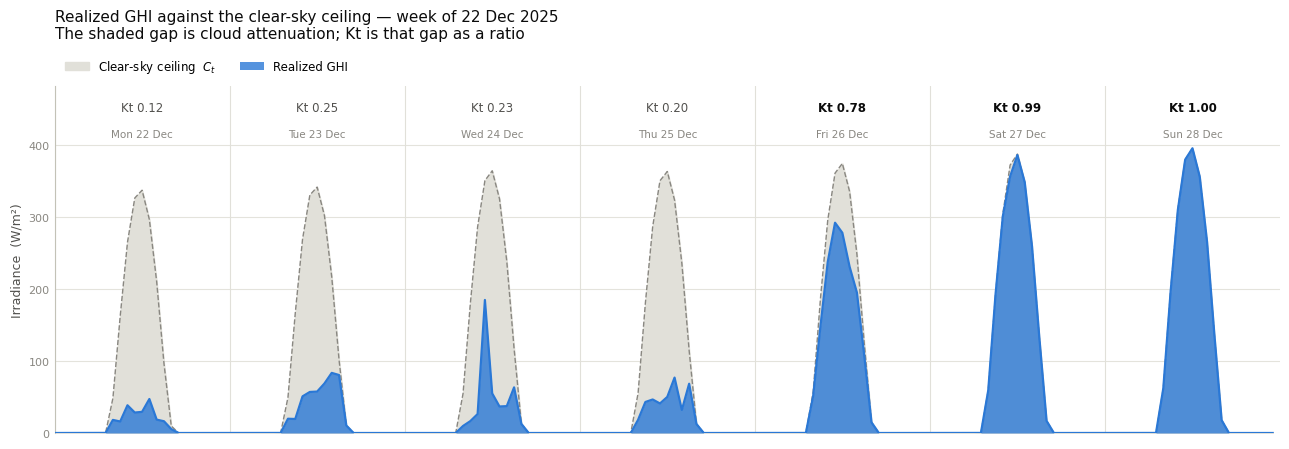

Week 2025-12-22 → 2025-12-28
  daily Kt : min 0.125   max 0.999   mean 0.511
  realized : 7,236 Wh/m²   of a possible 13,604 Wh/m²  (53.2%)


In [20]:
# ── Figure A — realized GHI vs the clear-sky ceiling, one week ────────────────
#
# The clear-sky curve is the deterministic astronomical ceiling C_t; realized GHI
# can only sit at or below it. The shaded gap between the two IS the cloud
# attenuation, and Kt = GHI / C_t is exactly that gap expressed as a ratio —
# the quantity the whole model is built on.

# Chosen as the widest Kt-spread week of 2025 (overcast start, near-clear finish),
# so both regimes appear in one frame. Set to None to re-pick automatically.
WEEK_START = "2025-12-22"

_h = df.copy()
_h["date"] = _h["time"].dt.normalize()

if WEEK_START is None:
    _d  = _h.groupby("date").agg(g=("GHI", "sum"), cs=("CLEAR_SKY_GHI", "sum"))
    _d  = _d[_d.index.year == 2025]
    _kt = (_d["g"] / _d["cs"])
    _spread = _kt.rolling(7).max() - _kt.rolling(7).min()
    WEEK_START = str((_spread.idxmax() - pd.Timedelta(days=6)).date())

_t0 = pd.Timestamp(WEEK_START)
_t1 = _t0 + pd.Timedelta(days=7)
_w  = _h[(_h["time"] >= _t0) & (_h["time"] < _t1)].sort_values("time")

_wd = (_w.groupby("date")
         .agg(GHI=("GHI", "sum"), CS=("CLEAR_SKY_GHI", "sum")))
_wd["Kt"] = _wd["GHI"] / _wd["CS"]

# ── palette (validated: see references/palette.md) ────────────────────────────
C_SERIES  = "#2a78d6"   # categorical slot 1 — realized GHI
C_CEIL    = "#e1e0d9"   # gridline step — the ceiling is chrome, not a rival series
C_CEIL_LN = "#898781"   # muted ink
INK, INK2, INK3 = "#0b0b0b", "#52514e", "#898781"

fig, ax = plt.subplots(figsize=(13, 4.6))

ax.fill_between(_w["time"], 0, _w["CLEAR_SKY_GHI"],
                color=C_CEIL, zorder=1, label="Clear-sky ceiling  $C_t$")
ax.plot(_w["time"], _w["CLEAR_SKY_GHI"],
        color=C_CEIL_LN, lw=1.0, ls="--", zorder=2)

ax.fill_between(_w["time"], 0, _w["GHI"],
                color=C_SERIES, alpha=0.80, lw=0, zorder=3,
                label="Realized GHI")
ax.plot(_w["time"], _w["GHI"], color=C_SERIES, lw=1.6, zorder=4)

# day separators + per-day Kt (selective direct labels — 7, not one per hour)
_ymax = float(_w["CLEAR_SKY_GHI"].max()) * 1.22
for _day, _row in _wd.iterrows():
    ax.axvline(_day, color=C_CEIL, lw=0.8, zorder=0)
    ax.text(_day + pd.Timedelta(hours=12), _ymax * 0.955,
            f"Kt {_row['Kt']:.2f}", ha="center", va="top",
            fontsize=8.5, color=INK if _row["Kt"] > 0.6 else INK2,
            fontweight="semibold" if _row["Kt"] > 0.6 else "normal")
    ax.text(_day + pd.Timedelta(hours=12), _ymax * 0.875,
            _day.strftime("%a %d %b"), ha="center", va="top",
            fontsize=7.5, color=INK3)

ax.set_ylim(0, _ymax)
ax.set_xlim(_t0, _t1)
ax.set_ylabel("Irradiance  (W/m²)", fontsize=9, color=INK2)
ax.set_xlabel("")
ax.set_xticks([])
ax.grid(axis="y", color=C_CEIL, lw=0.8, alpha=0.9, zorder=0)
ax.set_axisbelow(True)
for _s in ("top", "right", "bottom"):
    ax.spines[_s].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.tick_params(axis="y", labelsize=8, colors=INK3, length=0)

# legend sits OUTSIDE the axes: inside upper-left it collides with the
# first days' Kt labels, which are pinned to the top of the plot area.
ax.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0),
          frameon=False, fontsize=8.5, ncol=2)
ax.set_title(
    f"Realized GHI against the clear-sky ceiling — week of {_t0.strftime('%d %b %Y')}\n"
    f"The shaded gap is cloud attenuation; Kt is that gap as a ratio",
    fontsize=11, color=INK, loc="left", pad=34)

plt.tight_layout()
plt.show()

print(f"Week {_t0.date()} → {(_t1 - pd.Timedelta(days=1)).date()}")
print(f"  daily Kt : min {_wd['Kt'].min():.3f}   max {_wd['Kt'].max():.3f}   "
      f"mean {_wd['Kt'].mean():.3f}")
print(f"  realized : {_wd['GHI'].sum():,.0f} Wh/m²   of a possible "
      f"{_wd['CS'].sum():,.0f} Wh/m²  ({_wd['GHI'].sum()/_wd['CS'].sum():.1%})")

> **Takeaway.** Realized GHI tracks the clear-sky ceiling closely on the clear days and falls well below it on the overcast ones; the width of that gap across the week is the cloud attenuation `Kt` is built to summarise.

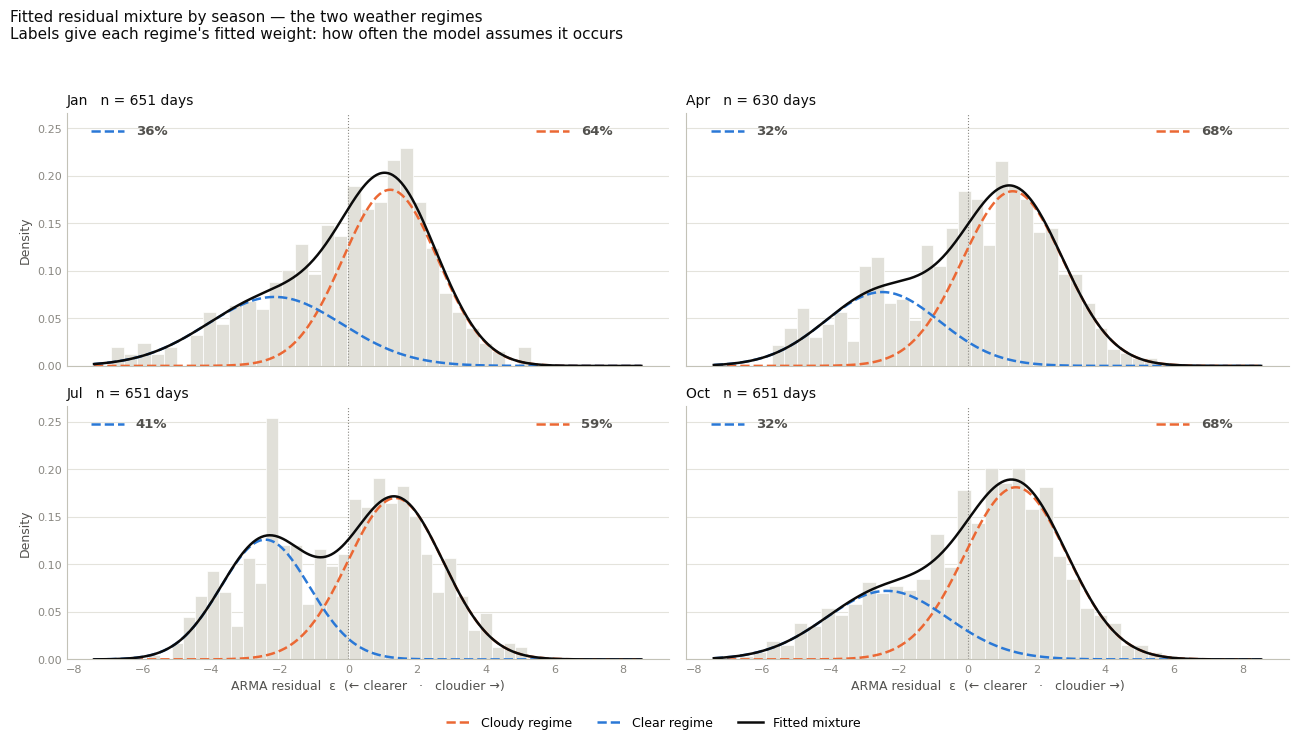

Month   w_cloudy mu_cloudy   w_clear   mu_clear
----------------------------------------------
Jan        0.643     1.220     0.357     -2.149
Apr        0.676     1.298     0.324     -2.503
Jul        0.592     1.372     0.408     -2.425
Oct        0.680     1.389     0.320     -2.373


In [21]:
# ── Figure B — fitted residual mixture, four representative months ───────────
#
# One panel per season. The histogram is the observed ARMA residual e_t for that
# month; the two dashed curves are the fitted mixture components scaled by their
# weights, and the solid dark curve is their sum — the density the simulation
# actually draws from. Regime names follow the summary table's convention.
#
# COMPONENT LABELLING (D4) — components are stored sorted by mean, so index 0
# is the LOWER-mean component and index 1 the higher-mean one. Y_t increases
# with cloudiness, so index 0 is the clear regime and index 1 the cloudy one --
# matching the corrected monthly summary table earlier in the notebook.
IDX_CLEAR, IDX_CLOUDY = 0, 1

PANEL_MONTHS = [1, 4, 7, 10]

# ── palette (validated all-pairs, light mode: CVD ΔE 24.7, normal ΔE 33.6) ────
C_CLEAR  = "#2a78d6"   # categorical slot 1
C_CLOUDY = "#eb6834"   # categorical slot 2
C_HIST   = "#e1e0d9"
INK, INK2, INK3 = "#0b0b0b", "#52514e", "#898781"

# sharey: the panels are compared against each other, so they must sit on
# one scale — it also stops matplotlib giving each panel its own tick format.
fig, axes = plt.subplots(2, 2, figsize=(13, 7.2), sharex=True, sharey=True)
_x = np.linspace(epsilon.min() - 0.5, epsilon.max() + 0.5, 400)

for _ax, _m in zip(axes.ravel(), PANEL_MONTHS):
    _e  = epsilon[months == _m].values
    _mp = mixture_params[_m]

    _ax.hist(_e, bins=32, density=True, color=C_HIST,
             edgecolor="white", linewidth=0.5, zorder=1)

    _pdfs = {}
    for _i, (_c, _lab) in [(IDX_CLOUDY, (C_CLOUDY, "Cloudy regime")),
                           (IDX_CLEAR,  (C_CLEAR,  "Clear regime"))]:
        _pdfs[_i] = _mp["weights"][_i] * norm.pdf(_x, _mp["means"][_i], _mp["stds"][_i])
        _ax.plot(_x, _pdfs[_i], color=_c, lw=1.8, ls="--", zorder=3,
                 label=_lab)

    _ax.plot(_x, _pdfs[IDX_CLOUDY] + _pdfs[IDX_CLEAR],
             color=INK, lw=1.8, zorder=4, label="Fitted mixture")
    _ax.axvline(0, color=INK3, lw=0.8, ls=":", zorder=2)

    # Direct labels — the weight answers "how often does this regime occur".
    # Placed in the panel's empty upper corners in AXES coordinates rather than
    # on the curves: both component peaks sit near the mixture ridge and the
    # outer flanks are steep, so any curve-anchored label gets struck through by
    # the black line. Left corner = clear regime, right = cloudy, mirroring
    # where each sits on the x-axis. The number wears ink; the colored swatch
    # beside it carries the identity.
    for _i, _c, _xs in [(IDX_CLEAR,  C_CLEAR,  0.04),
                        (IDX_CLOUDY, C_CLOUDY, 0.78)]:
        _ax.plot([_xs, _xs + 0.055], [0.93, 0.93], color=_c, lw=1.8, ls="--",
                 transform=_ax.transAxes, clip_on=False, zorder=5)
        _ax.text(_xs + 0.075, 0.93, f"{_mp['weights'][_i]:.0%}",
                 transform=_ax.transAxes, va="center", ha="left",
                 fontsize=9.5, color=INK2, fontweight="semibold", zorder=5)

    _ax.set_title(f"{MONTH_NAMES[_m-1]}   n = {len(_e):,} days",
                  fontsize=10, color=INK, loc="left")
    _ax.grid(axis="y", color=C_HIST, lw=0.8, alpha=0.9)
    _ax.set_axisbelow(True)
    for _s in ("top", "right"):
        _ax.spines[_s].set_visible(False)
    _ax.spines["left"].set_color("#c3c2b7")
    _ax.spines["bottom"].set_color("#c3c2b7")
    _ax.tick_params(labelsize=8, colors=INK3, length=0)

for _ax in axes[:, 0]:
    _ax.set_ylabel("Density", fontsize=9, color=INK2)
for _ax in axes[1, :]:
    _ax.set_xlabel("ARMA residual  ε  (← clearer   ·   cloudier →)",
                   fontsize=9, color=INK2)

_h, _l = axes[0, 0].get_legend_handles_labels()
fig.legend(_h, _l, loc="lower center", ncol=3, frameon=False,
           fontsize=9, bbox_to_anchor=(0.5, -0.015))
fig.suptitle(
    "Fitted residual mixture by season — the two weather regimes\n"
    "Labels give each regime's fitted weight: how often the model assumes it occurs",
    fontsize=11, color=INK, x=0.005, ha="left", y=1.0)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

print(f"{'Month':<6} {'w_cloudy':>9} {'mu_cloudy':>9} {'w_clear':>9} {'mu_clear':>10}")
print("-" * 46)
for _m in PANEL_MONTHS:
    _mp = mixture_params[_m]
    print(f"{MONTH_NAMES[_m-1]:<6} "
          f"{_mp['weights'][IDX_CLOUDY]:>9.3f} {_mp['means'][IDX_CLOUDY]:>9.3f} "
          f"{_mp['weights'][IDX_CLEAR]:>9.3f} {_mp['means'][IDX_CLEAR]:>10.3f}")

> **Takeaway.** The fitted two-component mixture (dashed) sums to a density (solid) that tracks the observed residual histogram in every season shown, including the bimodal shape in the transition months -- the justification for D4 over a single Gaussian.

## Limitations & Handoff

- **Support is capped by construction.** Alpha and beta are fitted from the
  sample's own min/max of cloudiness, so no simulated day can be cloudier
  than the cloudiest day observed 2005-2025. This bounds tail severity in
  any downside-risk work built on these paths.
- **One harmonic is a serialization contract, not a statistical optimum**
  (D2): the 3-element `ghi_seasonal_coeffs.pkl` vector is unpacked
  positionally by the reconstruction notebooks, so the residual monthly
  offset a second harmonic would remove is absorbed by the mixture means
  instead. The decomposition is non-canonical; the simulated marginal is not.
- **The full-sample fit and the holdout-validated fit are two different
  estimates.** The artifacts saved above are fit on the complete
  2005-2025 record; the accuracy numbers in Validation come from a
  train-only refit on the first 16 years. Both are reported, but only the
  full-sample one is deployed.

**Next notebook can rely on:** `Data/Modelled/df_solar_modelled.parquet`
(columns `Kt`, `GHI_obs`, `GHI_cs`, `Yt`, `Y_bar`, `Y_tilde`,
`Ytilde_fitted`, `epsilon`, `Kt_fitted`, `Kt_residuals`, indexed by `date`)
and the three pickles plus `model_meta.json` in `Code/Models/GHI - KT/`, read
by `Code/Modelling/06_copula.ipynb` and the Simulation-stage reconstruction
notebooks.